In [1]:
# Heatmaps

In [1]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/Pilot_2_Prostate/notebooks/Post-hoc_Analysis


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Hierarchical clustering

In [4]:
res_tcga = pd.read_excel("../../results/TCGA/TCGA_NetBID2_ms_tab.xlsx")
res_tcga = res_tcga[['originalID', 'funcType', 'Size',
                     'logFC.U.Vs.M_DA', 'adj.P.Val.U.Vs.M_DA', 'Z.U.Vs.M_DA',
                     'logFC.U.Vs.M_DE', 'adj.P.Val.U.Vs.M_DE', 'Z.U.Vs.M_DE']]

res_tcga.rename(columns={
    'originalID': 'ID',
    'funcType': 'Type',
    'logFC.U.Vs.M_DA': 'logFC_DA',
    'adj.P.Val.U.Vs.M_DA': 'adj.P.Val_DA',
    'Z.U.Vs.M_DA': 'Z-score_DA',
    'logFC.U.Vs.M_DE': 'logFC_DE',
    'adj.P.Val.U.Vs.M_DE': 'adj.P.Val_DE',
    'Z.U.Vs.M_DE': 'Z-score_DE',
}, inplace=True)

# Create a temporary column to give priority to "TF" rows
res_tcga['priority'] = res_tcga['Type'].apply(lambda x: 0 if x == 'TF' else 1)

# Sort by priority and ID
res_tcga = res_tcga.sort_values(by=['priority', 'ID'])

# Drop duplicates, keeping TF first
res_tcga = res_tcga.drop_duplicates(subset='ID', keep='first')

# Drop helper column
res_tcga = res_tcga.drop(columns=['priority'])

# Apply filters
res_tcga_filt_overt = res_tcga[
    (res_tcga['adj.P.Val_DA'] < 0.05) &
    (res_tcga['adj.P.Val_DE'] < 0.05) &
    (res_tcga['Size'] > 30)
]

res_tcga_filt_hidden = res_tcga[
    (res_tcga['adj.P.Val_DA'] < 0.05) &
    (res_tcga['adj.P.Val_DE'] > 0.05) &
    (res_tcga['Size'] > 30)
]

# Print summary
print("Overt Drivers:", len(res_tcga_filt_overt))
print("Hidden Drivers:", len(res_tcga_filt_hidden))
print("Overt TFs:", len(res_tcga_filt_overt[res_tcga_filt_overt['Type'] == "TF"]))
print("Overt SIGs:", len(res_tcga_filt_overt[res_tcga_filt_overt['Type'] == "SIG"]))
print("Overt NCs:", len(res_tcga_filt_overt[res_tcga_filt_overt['Type'] == "NC"]))
print("Hidden TFs:", len(res_tcga_filt_hidden[res_tcga_filt_hidden['Type'] == "TF"]))
print("Hidden SIGs:", len(res_tcga_filt_hidden[res_tcga_filt_hidden['Type'] == "SIG"]))
print("Hidden NCs:", len(res_tcga_filt_hidden[res_tcga_filt_hidden['Type'] == "NC"]))


Overt Drivers: 2609
Hidden Drivers: 1722
Overt TFs: 380
Overt SIGs: 1283
Overt NCs: 946
Hidden TFs: 290
Hidden SIGs: 649
Hidden NCs: 783


In [6]:
shap_validation_go = pd.read_csv("../../PASNet/Output/GO/feature_importance_table.csv", index_col=0)
shap_validation_go_top20 = shap_validation_go.sort_values(by="Importance", ascending=False).head(50)

shap_validation_rest = pd.read_csv("../../PASNet/Output/REST/feature_importance_table.csv", index_col=0)
shap_validation_rest_top20 = shap_validation_rest.sort_values(by="Importance", ascending=False).head(50)

In [7]:
# Step 1: Get the feature names (index) from both DataFrames
features_rest = shap_validation_rest_top20.index
features_go = shap_validation_go_top20.index

# Step 2: Combine the feature names
combined_features = features_rest.to_list() + features_go.to_list()

# Step 3: Remove duplicates
unique_features = pd.Index(combined_features).unique()

# Optional: Convert to DataFrame if needed
features_df = pd.DataFrame(unique_features, columns=['Feature'])

In [8]:
res_tcga_filt = res_tcga[res_tcga['ID'].isin(features_df['Feature'])]
len(res_tcga_filt)

84

In [7]:
res_tcga_filt[res_tcga_filt['Type'] == "NC"]['ID'].tolist()

['FRY-AS1', 'HCG11', 'HLA-DQB1-AS1', 'LINC01082', 'LINC01088', 'PRC1-AS1']

/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


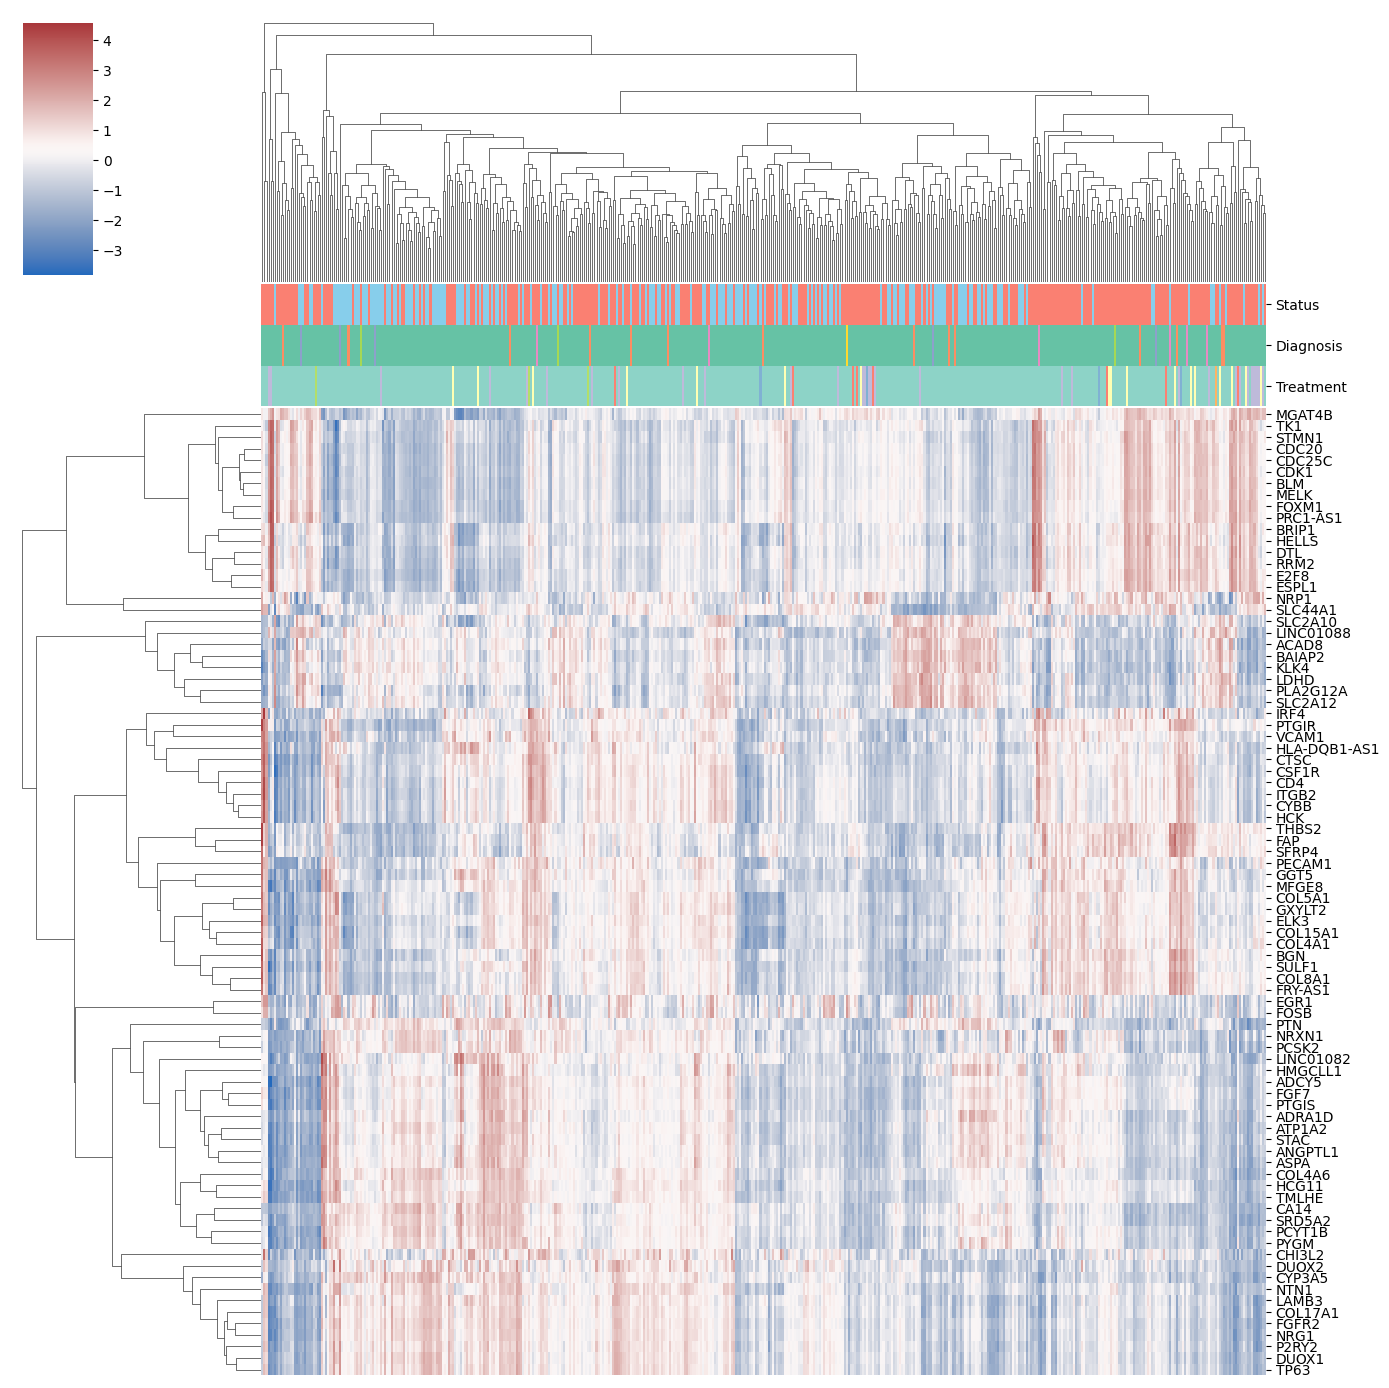

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
count_matrix = pd.read_csv("../../../data/TCGA/activity_ens.csv", index_col=0)
clinical = pd.read_excel("../../../data/TCGA/clinical_info.xlsx")

# Set Sample_ID as index
clinical = clinical.set_index('Sample_ID')

# Keep only samples present in both datasets
common_samples = count_matrix.columns.intersection(clinical.index)
count_matrix = count_matrix[common_samples]
clinical = clinical.loc[common_samples]

# Subset genes of interest
genes_of_interest = res_tcga_filt['ID'].tolist()  # replace with your gene symbols
count_matrix_subset = count_matrix.loc[count_matrix.index.intersection(genes_of_interest)]

# Create color palettes for annotations
status_colors = {'Mild': 'skyblue', 'Progressive': 'salmon'}
diagnosis_colors = {cls: color for cls, color in zip(clinical['diagnoses.classification_of_tumor'].unique(), sns.color_palette("Set2", n_colors=clinical['diagnoses.classification_of_tumor'].nunique()))}
treatment_colors = {out: color for out, color in zip(clinical['treatments.treatment_outcome'].unique(), sns.color_palette("Set3", n_colors=clinical['treatments.treatment_outcome'].nunique()))}

# Map clinical annotations to colors
col_colors = pd.DataFrame({
    'Status': clinical['Status'].map(status_colors),
    'Diagnosis': clinical['diagnoses.classification_of_tumor'].map(diagnosis_colors),
    'Treatment': clinical['treatments.treatment_outcome'].map(treatment_colors)
})

# Plot clustered heatmap
g = sns.clustermap(
    count_matrix_subset,
    cmap="vlag",
    z_score=0,           # row-wise z-score normalization
    row_cluster=True,
    col_cluster=True,
    col_colors=col_colors,
    xticklabels=False,
    yticklabels=True,
    figsize=(14, 14)
)

# Save figure
g.fig.savefig("../../figures/TCGA_clustermap.png", dpi=300)
plt.show()


/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


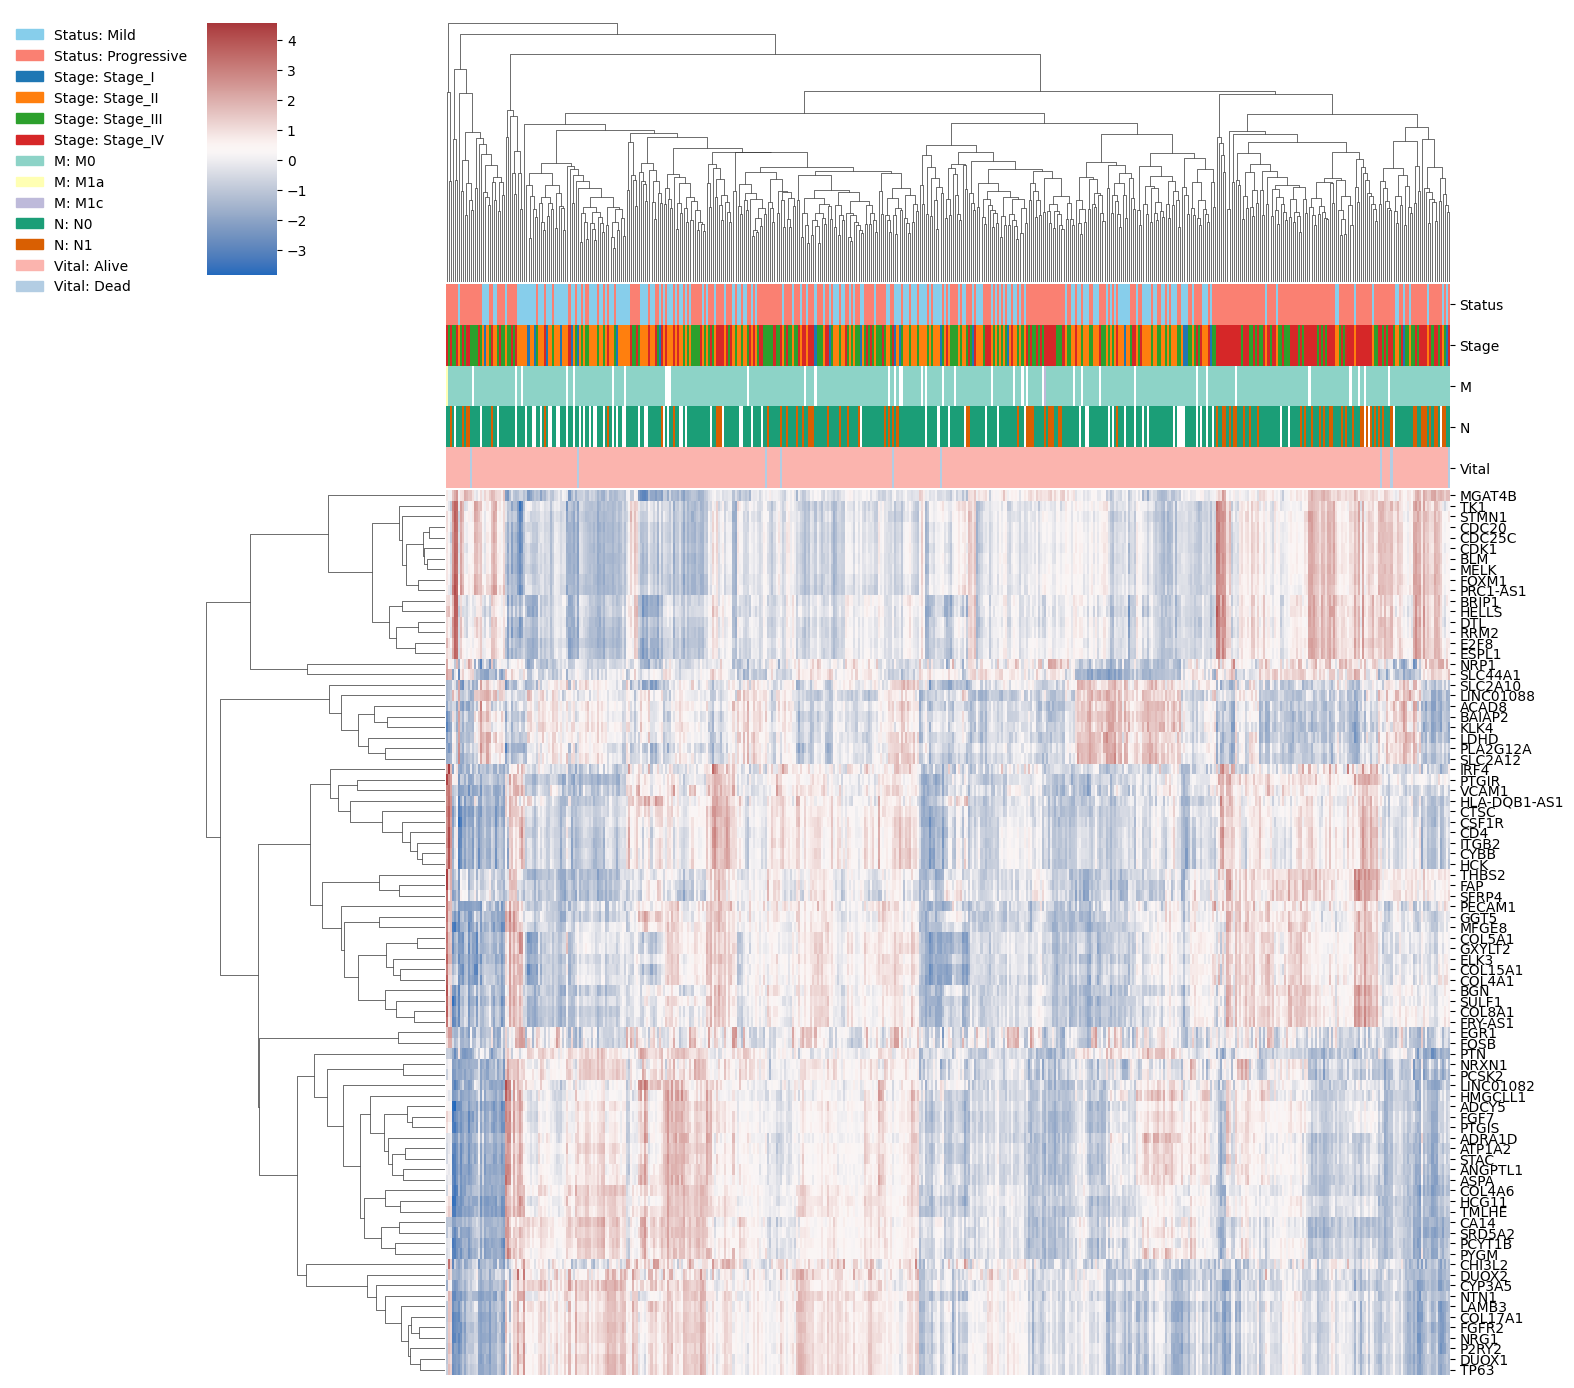

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Load data
count_matrix = pd.read_csv("../../../data/TCGA/activity_ens.csv", index_col=0)
clinical = pd.read_excel("../../../data/TCGA/clinical_info.xlsx")

# Set Sample_ID as index
clinical = clinical.set_index('Sample_ID')

# Keep only samples present in both datasets
common_samples = count_matrix.columns.intersection(clinical.index)
count_matrix = count_matrix[common_samples]
clinical = clinical.loc[common_samples]

# Subset genes of interest
genes_of_interest = res_tcga_filt['ID'].tolist()  # replace with your gene symbols
count_matrix_subset = count_matrix.loc[count_matrix.index.intersection(genes_of_interest)]

# -----------------------------
# Create color palettes for annotations
# -----------------------------
status_colors = {'Mild': 'skyblue', 'Progressive': 'salmon'}

# Use a more distinct palette for Stage
stage_unique = clinical['Status_stages'].dropna().unique()
stage_colors = {
    stage: color for stage, color in zip(
        stage_unique,
        sns.color_palette("tab10", n_colors=len(stage_unique))  # brighter, distinct
    )
}

m_colors = {
    m: color for m, color in zip(
        clinical['ajcc_clinical_m'].dropna().unique(),
        sns.color_palette("Set3", n_colors=clinical['ajcc_clinical_m'].nunique())
    )
}

n_colors = {
    n: color for n, color in zip(
        clinical['ajcc_pathologic_n'].dropna().unique(),
        sns.color_palette("Dark2", n_colors=clinical['ajcc_pathologic_n'].nunique())
    )
}

vital_colors = {
    vs: color for vs, color in zip(
        clinical['demographic.vital_status'].dropna().unique(),
        sns.color_palette("Pastel1", n_colors=clinical['demographic.vital_status'].nunique())
    )
}

# -----------------------------
# Map clinical annotations to colors
# -----------------------------
col_colors = pd.DataFrame({
    'Status': clinical['Status'].map(status_colors),
    'Stage': clinical['Status_stages'].map(stage_colors),
    'M': clinical['ajcc_clinical_m'].map(m_colors),
    'N': clinical['ajcc_pathologic_n'].map(n_colors),
    'Vital': clinical['demographic.vital_status'].map(vital_colors)
})

# -----------------------------
# Plot clustered heatmap
# -----------------------------
g = sns.clustermap(
    count_matrix_subset,
    cmap="vlag",
    z_score=0,           # row-wise z-score normalization
    row_cluster=True,
    col_cluster=True,
    col_colors=col_colors,
    xticklabels=False,
    yticklabels=True,
    figsize=(14, 14)
)

# -----------------------------
# Add legends for clinical annotations (LEFT of plot)
# -----------------------------
legend_patches = []

# Status
legend_patches += [Patch(color=color, label=f"Status: {label}") for label, color in status_colors.items()]
# Stage
legend_patches += [Patch(color=color, label=f"Stage: {label}") for label, color in stage_colors.items()]
# AJCC M
legend_patches += [Patch(color=color, label=f"M: {label}") for label, color in m_colors.items()]
# AJCC N
legend_patches += [Patch(color=color, label=f"N: {label}") for label, color in n_colors.items()]
# Vital Status
legend_patches += [Patch(color=color, label=f"Vital: {label}") for label, color in vital_colors.items()]

plt.legend(
    handles=legend_patches,
    bbox_to_anchor=(-0.2, 1),   # move legend outside to the LEFT
    loc='upper right',
    borderaxespad=0.,
    frameon=False
)

# Save figure
g.fig.savefig("../../figures/TCGA_clustermap.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# lncRNAs only

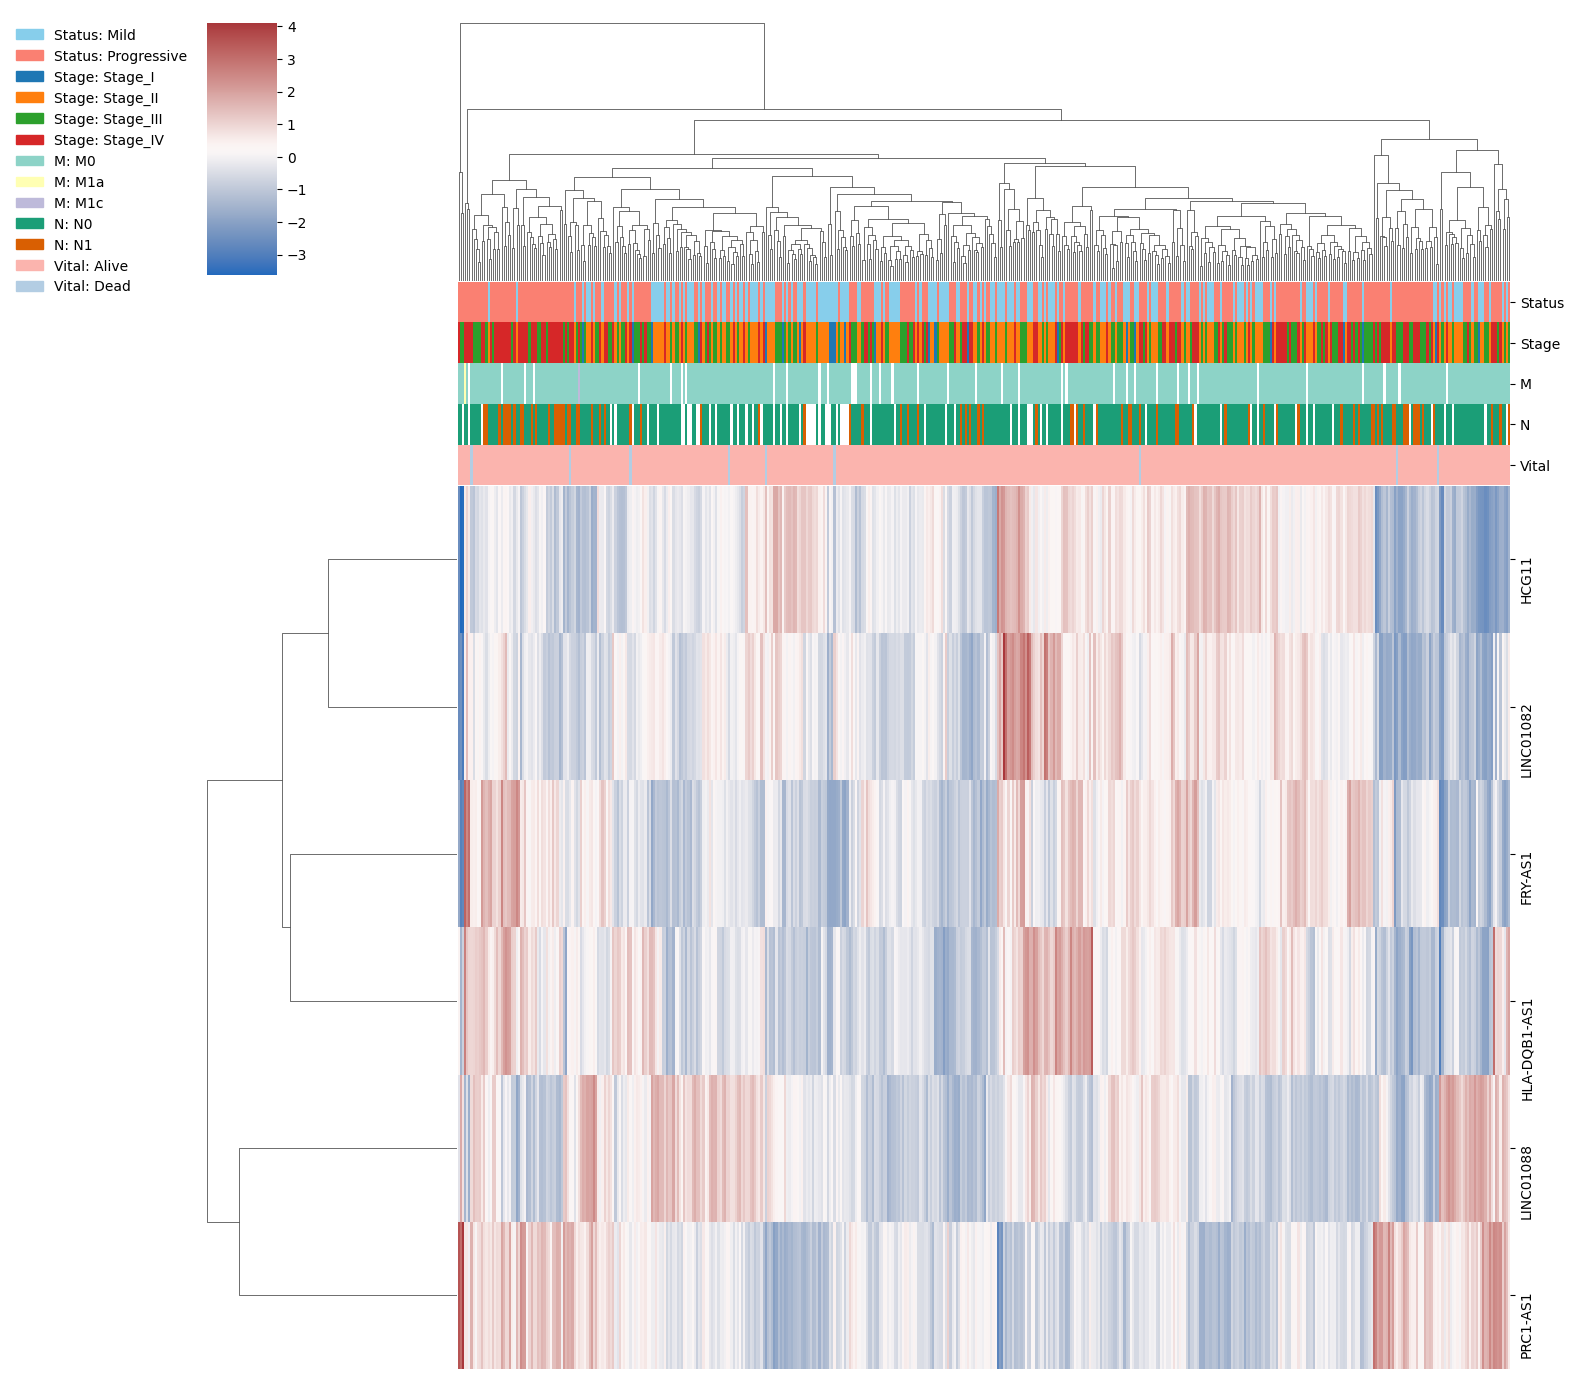

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Load data
count_matrix = pd.read_csv("../../../data/TCGA/activity_ens.csv", index_col=0)
clinical = pd.read_excel("../../../data/TCGA/clinical_info.xlsx")

# Set Sample_ID as index
clinical = clinical.set_index('Sample_ID')

# Keep only samples present in both datasets
common_samples = count_matrix.columns.intersection(clinical.index)
count_matrix = count_matrix[common_samples]
clinical = clinical.loc[common_samples]

# Subset genes of interest
genes_of_interest = res_tcga_filt[res_tcga_filt['Type'] == "NC"]['ID'].tolist()  # replace with your gene symbols
count_matrix_subset = count_matrix.loc[count_matrix.index.intersection(genes_of_interest)]

# -----------------------------
# Create color palettes for annotations
# -----------------------------
status_colors = {'Mild': 'skyblue', 'Progressive': 'salmon'}

# Use a more distinct palette for Stage
stage_unique = clinical['Status_stages'].dropna().unique()
stage_colors = {
    stage: color for stage, color in zip(
        stage_unique,
        sns.color_palette("tab10", n_colors=len(stage_unique))  # brighter, distinct
    )
}

m_colors = {
    m: color for m, color in zip(
        clinical['ajcc_clinical_m'].dropna().unique(),
        sns.color_palette("Set3", n_colors=clinical['ajcc_clinical_m'].nunique())
    )
}

n_colors = {
    n: color for n, color in zip(
        clinical['ajcc_pathologic_n'].dropna().unique(),
        sns.color_palette("Dark2", n_colors=clinical['ajcc_pathologic_n'].nunique())
    )
}

vital_colors = {
    vs: color for vs, color in zip(
        clinical['demographic.vital_status'].dropna().unique(),
        sns.color_palette("Pastel1", n_colors=clinical['demographic.vital_status'].nunique())
    )
}

# -----------------------------
# Map clinical annotations to colors
# -----------------------------
col_colors = pd.DataFrame({
    'Status': clinical['Status'].map(status_colors),
    'Stage': clinical['Status_stages'].map(stage_colors),
    'M': clinical['ajcc_clinical_m'].map(m_colors),
    'N': clinical['ajcc_pathologic_n'].map(n_colors),
    'Vital': clinical['demographic.vital_status'].map(vital_colors)
})

# -----------------------------
# Plot clustered heatmap
# -----------------------------
g = sns.clustermap(
    count_matrix_subset,
    cmap="vlag",
    z_score=0,           # row-wise z-score normalization
    row_cluster=True,
    col_cluster=True,
    col_colors=col_colors,
    xticklabels=False,
    yticklabels=True,
    figsize=(14, 14)
)

# -----------------------------
# Add legends for clinical annotations (LEFT of plot)
# -----------------------------
legend_patches = []

# Status
legend_patches += [Patch(color=color, label=f"Status: {label}") for label, color in status_colors.items()]
# Stage
legend_patches += [Patch(color=color, label=f"Stage: {label}") for label, color in stage_colors.items()]
# AJCC M
legend_patches += [Patch(color=color, label=f"M: {label}") for label, color in m_colors.items()]
# AJCC N
legend_patches += [Patch(color=color, label=f"N: {label}") for label, color in n_colors.items()]
# Vital Status
legend_patches += [Patch(color=color, label=f"Vital: {label}") for label, color in vital_colors.items()]

plt.legend(
    handles=legend_patches,
    bbox_to_anchor=(-0.2, 1),   # move legend outside to the LEFT
    loc='upper right',
    borderaxespad=0.,
    frameon=False
)

# Save figure
g.fig.savefig("../../figures/TCGA_clustermap.png", dpi=300, bbox_inches="tight")
plt.show()


/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


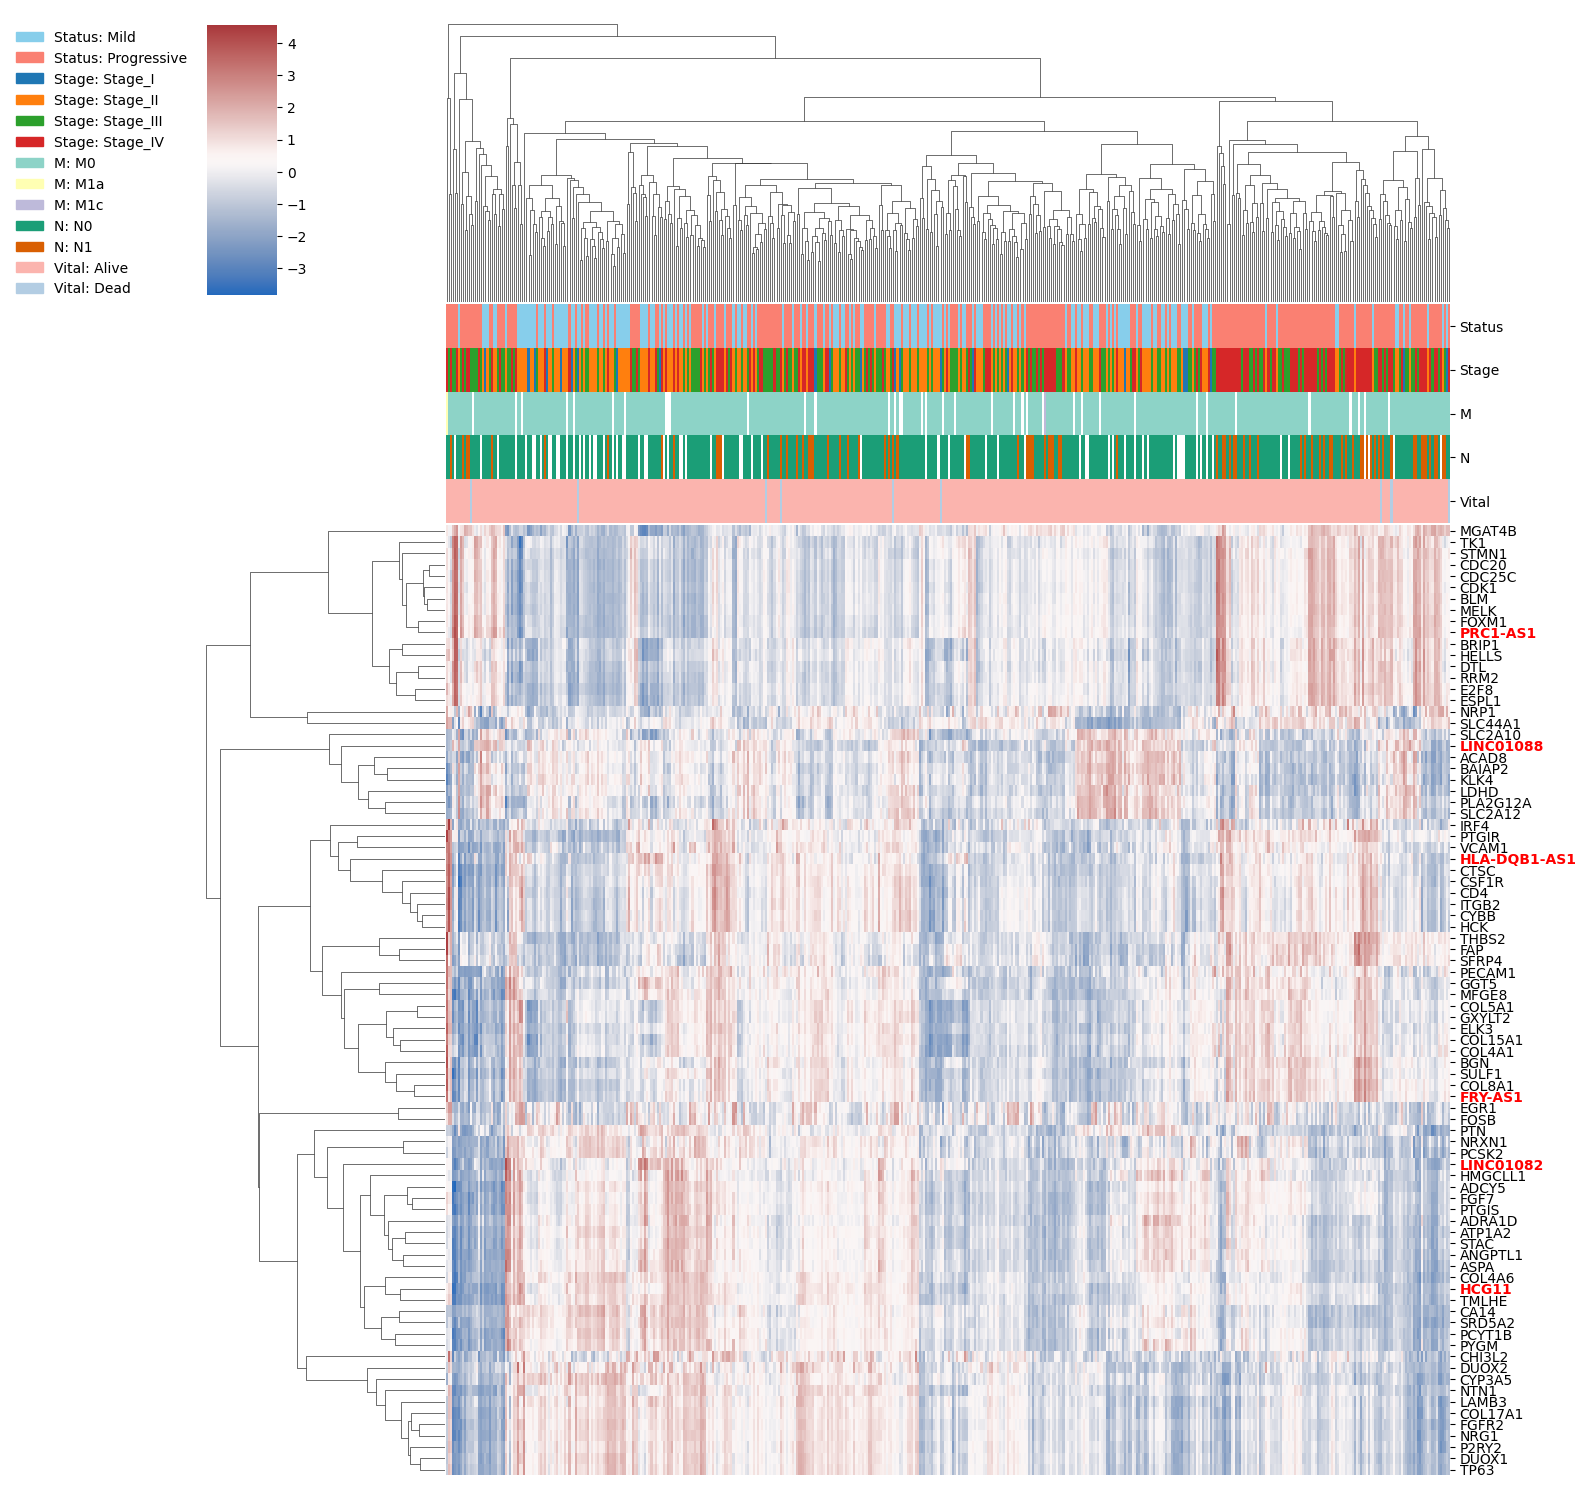

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Load data
count_matrix = pd.read_csv("../../../data/TCGA/activity_ens.csv", index_col=0)
clinical = pd.read_excel("../../../data/TCGA/clinical_info.xlsx")

# Set Sample_ID as index
clinical = clinical.set_index('Sample_ID')

# Keep only samples present in both datasets
common_samples = count_matrix.columns.intersection(clinical.index)
count_matrix = count_matrix[common_samples]
clinical = clinical.loc[common_samples]

# -----------------------------
# Define genes of interest (Type == "NC")
# -----------------------------
genes_of_interest = res_tcga_filt[res_tcga_filt['Type'] == "NC"]['ID'].tolist()
count_matrix_subset = count_matrix.loc[count_matrix.index.intersection(res_tcga_filt['ID'].tolist())]

# -----------------------------
# Create color palettes for annotations
# -----------------------------
status_colors = {'Mild': 'skyblue', 'Progressive': 'salmon'}

# Distinct colors for Stage
stage_unique = clinical['Status_stages'].dropna().unique()
stage_colors = {
    stage: color for stage, color in zip(
        stage_unique,
        sns.color_palette("tab10", n_colors=len(stage_unique))
    )
}

m_colors = {
    m: color for m, color in zip(
        clinical['ajcc_clinical_m'].dropna().unique(),
        sns.color_palette("Set3", n_colors=clinical['ajcc_clinical_m'].nunique())
    )
}

n_colors = {
    n: color for n, color in zip(
        clinical['ajcc_pathologic_n'].dropna().unique(),
        sns.color_palette("Dark2", n_colors=clinical['ajcc_pathologic_n'].nunique())
    )
}

vital_colors = {
    vs: color for vs, color in zip(
        clinical['demographic.vital_status'].dropna().unique(),
        sns.color_palette("Pastel1", n_colors=clinical['demographic.vital_status'].nunique())
    )
}

# -----------------------------
# Map clinical annotations to colors
# -----------------------------
col_colors = pd.DataFrame({
    'Status': clinical['Status'].map(status_colors),
    'Stage': clinical['Status_stages'].map(stage_colors),
    'M': clinical['ajcc_clinical_m'].map(m_colors),
    'N': clinical['ajcc_pathologic_n'].map(n_colors),
    'Vital': clinical['demographic.vital_status'].map(vital_colors)
})

# -----------------------------
# Plot clustered heatmap
# -----------------------------
g = sns.clustermap(
    count_matrix_subset,
    cmap="vlag",
    z_score=0,
    row_cluster=True,
    col_cluster=True,
    col_colors=col_colors,
    xticklabels=False,
    yticklabels=True,
    figsize=(14, 15)
)

# -----------------------------
# Highlight "NC" genes in RED
# -----------------------------
ax = g.ax_heatmap
for label in ax.get_yticklabels():
    if label.get_text() in genes_of_interest:
        label.set_color("red")
        label.set_fontweight("bold")

# -----------------------------
# Add legends for clinical annotations (LEFT of plot)
# -----------------------------
legend_patches = []
legend_patches += [Patch(color=color, label=f"Status: {label}") for label, color in status_colors.items()]
legend_patches += [Patch(color=color, label=f"Stage: {label}") for label, color in stage_colors.items()]
legend_patches += [Patch(color=color, label=f"M: {label}") for label, color in m_colors.items()]
legend_patches += [Patch(color=color, label=f"N: {label}") for label, color in n_colors.items()]
legend_patches += [Patch(color=color, label=f"Vital: {label}") for label, color in vital_colors.items()]

plt.legend(
    handles=legend_patches,
    bbox_to_anchor=(-0.2, 1),
    loc='upper right',
    borderaxespad=0.,
    frameon=False
)

# Save figure
g.fig.savefig("../../figures/TCGA_clustermap_highlightNC.png", dpi=300, bbox_inches="tight")
plt.show()


/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)



Cluster 1 (16 genes):
['BLM', 'BRIP1', 'CDC20', 'CDC25C', 'CDK1', 'DTL', 'E2F8', 'ESPL1', 'FOXM1', 'HELLS', 'MELK', 'MGAT4B', 'PRC1-AS1', 'RRM2', 'STMN1', 'TK1']

Cluster 2 (2 genes):
['NRP1', 'SLC44A1']

Cluster 3 (8 genes):
['ACAD8', 'BAIAP2', 'KLK4', 'LDHD', 'LINC01088', 'PLA2G12A', 'SLC2A10', 'SLC2A12']

Cluster 4 (25 genes):
['BGN', 'CD4', 'COL15A1', 'COL4A1', 'COL5A1', 'COL8A1', 'CSF1R', 'CTSC', 'CYBB', 'ELK3', 'FAP', 'FRY-AS1', 'GGT5', 'GXYLT2', 'HCK', 'HLA-DQB1-AS1', 'IRF4', 'ITGB2', 'MFGE8', 'PECAM1', 'PTGIR', 'SFRP4', 'SULF1', 'THBS2', 'VCAM1']

Cluster 5 (33 genes):
['ADCY5', 'ADRA1D', 'ANGPTL1', 'ASPA', 'ATP1A2', 'CA14', 'CHI3L2', 'COL17A1', 'COL4A6', 'CYP3A5', 'DUOX1', 'DUOX2', 'EGR1', 'FGF7', 'FGFR2', 'FOSB', 'HCG11', 'HMGCLL1', 'LAMB3', 'LINC01082', 'NRG1', 'NRXN1', 'NTN1', 'P2RY2', 'PCSK2', 'PCYT1B', 'PTGIS', 'PTN', 'PYGM', 'SRD5A2', 'STAC', 'TMLHE', 'TP63']


/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


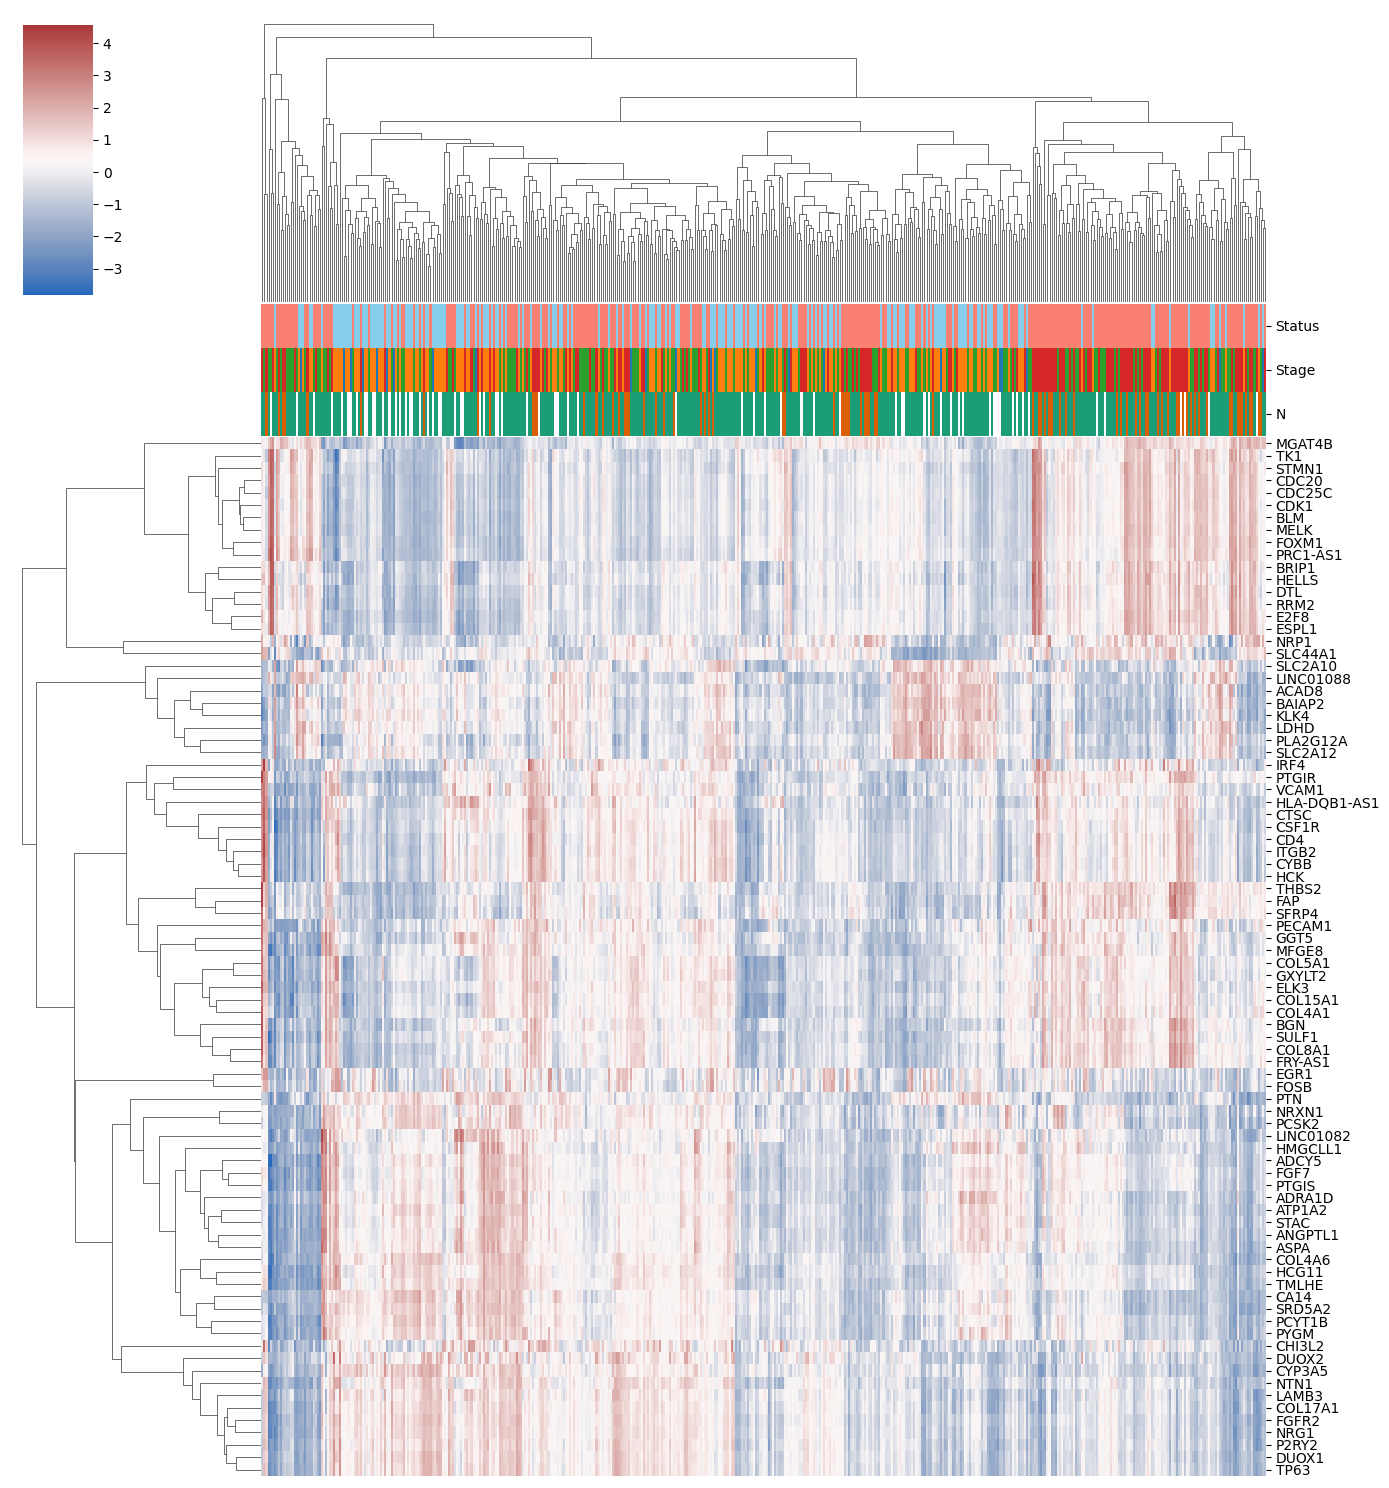

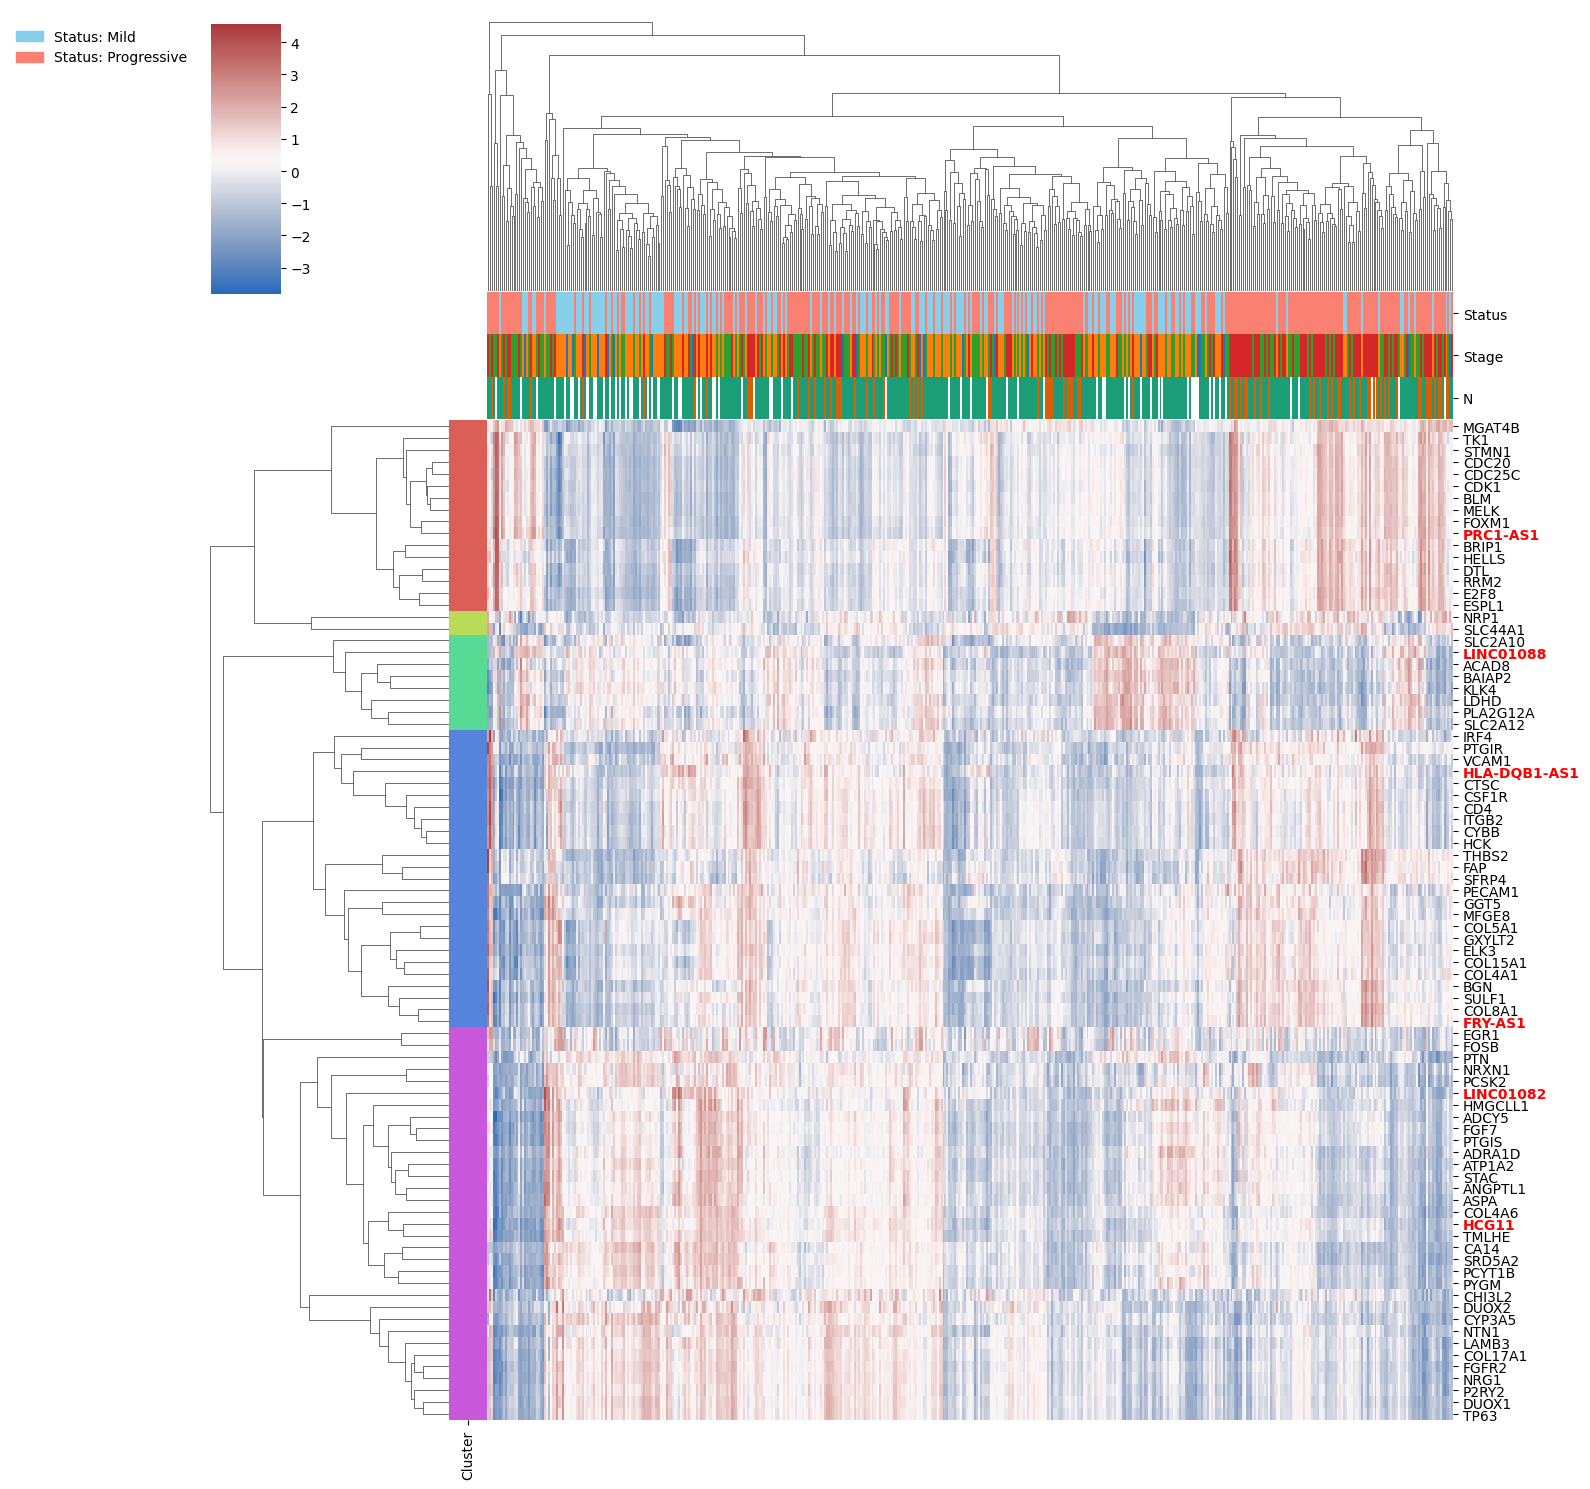

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import fcluster

# -----------------------------
# Load data
# -----------------------------
count_matrix = pd.read_csv("../../../data/TCGA/activity_ens.csv", index_col=0)
clinical = pd.read_excel("../../../data/TCGA/clinical_info.xlsx")

# Set Sample_ID as index
clinical = clinical.set_index('Sample_ID')

# Keep only samples present in both datasets
common_samples = count_matrix.columns.intersection(clinical.index)
count_matrix = count_matrix[common_samples]
clinical = clinical.loc[common_samples]

# -----------------------------
# Define genes of interest (Type == "NC")
# -----------------------------
genes_of_interest = res_tcga_filt[res_tcga_filt['Type'] == "NC"]['ID'].tolist()
count_matrix_subset = count_matrix.loc[count_matrix.index.intersection(res_tcga_filt['ID'].tolist())]

# -----------------------------
# Create color palettes for annotations
# -----------------------------
status_colors = {'Mild': 'skyblue', 'Progressive': 'salmon'}
stage_unique = clinical['Status_stages'].dropna().unique()
stage_colors = {stage: color for stage, color in zip(stage_unique, sns.color_palette("tab10", n_colors=len(stage_unique)))}
n_colors = {n: color for n, color in zip(clinical['ajcc_pathologic_n'].dropna().unique(), sns.color_palette("Dark2", n_colors=clinical['ajcc_pathologic_n'].nunique()))}

# Map clinical annotations to colors (exclude M and Vital)
col_colors = pd.DataFrame({
    'Status': clinical['Status'].map(status_colors),
    'Stage': clinical['Status_stages'].map(stage_colors),
    'N': clinical['ajcc_pathologic_n'].map(n_colors)
})

# -----------------------------
# Cluster genes (rows)
# -----------------------------
k = 5  # number of row clusters

# Create the initial clustermap
g = sns.clustermap(
    count_matrix_subset,
    cmap="vlag",
    z_score=0,
    row_cluster=True,
    col_cluster=True,
    col_colors=col_colors,
    xticklabels=False,
    yticklabels=True,
    figsize=(14, 15)
)

# Extract row clusters from dendrogram
row_linkage = g.dendrogram_row.linkage
row_clusters = fcluster(row_linkage, k, criterion='maxclust')

# Assign colors to clusters
cluster_palette = sns.color_palette("hls", k)
cluster_colors = {i: cluster_palette[i-1] for i in range(1, k+1)}
row_colors = pd.DataFrame({"Cluster": [cluster_colors[c] for c in row_clusters]}, index=count_matrix_subset.index)

# -----------------------------
# Map genes to clusters and save
# -----------------------------
gene_clusters = pd.DataFrame({
    'Gene': count_matrix_subset.index,
    'Cluster': row_clusters
})
gene_clusters.to_csv("../../figures/TCGA_gene_clusters.csv", index=False)

# Dictionary of genes per cluster
genes_per_cluster = {i: gene_clusters[gene_clusters['Cluster'] == i]['Gene'].tolist() for i in range(1, k+1)}

# Print clusters
for cluster_id, genes in genes_per_cluster.items():
    print(f"\nCluster {cluster_id} ({len(genes)} genes):")
    print(genes)

# -----------------------------
# Replot with row_colors
# -----------------------------
g = sns.clustermap(
    count_matrix_subset,
    cmap="vlag",
    z_score=0,
    row_cluster=True,
    col_cluster=True,
    col_colors=col_colors,
    row_colors=row_colors,
    xticklabels=False,
    yticklabels=True,
    figsize=(14, 15)
)

# Highlight "NC" genes in RED
ax = g.ax_heatmap
for label in ax.get_yticklabels():
    if label.get_text() in genes_of_interest:
        label.set_color("red")
        label.set_fontweight("bold")

# -----------------------------
# Add legends
# -----------------------------
legend_patches = []
legend_patches += [Patch(color=color, label=f"Status: {label}") for label, color in status_colors.items()]
legend_patches += [Patch(color=color, label=f"Stage: {label}") for label, color in stage_colors.items()]
legend_patches += [Patch(color=color, label=f"N: {label}") for label, color in n_colors.items()]
#legend_patches += [Patch(color=color, label=f"Gene Cluster {i}") for i, color in cluster_colors.items()]

plt.legend(
    handles=legend_patches,
    bbox_to_anchor=(-0.25, 1),
    loc='upper right',
    borderaxespad=0.,
    frameon=False
)

# -----------------------------
# Save figure
# -----------------------------
g.fig.savefig("../../figures/TCGA_clustermap_highlightNC_clustered.png", dpi=300, bbox_inches="tight")
plt.show()


/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)



Cluster 1 (16 genes):
['BLM', 'BRIP1', 'CDC20', 'CDC25C', 'CDK1', 'DTL', 'E2F8', 'ESPL1', 'FOXM1', 'HELLS', 'MELK', 'MGAT4B', 'PRC1-AS1', 'RRM2', 'STMN1', 'TK1']

Cluster 2 (2 genes):
['NRP1', 'SLC44A1']

Cluster 3 (8 genes):
['ACAD8', 'BAIAP2', 'KLK4', 'LDHD', 'LINC01088', 'PLA2G12A', 'SLC2A10', 'SLC2A12']

Cluster 4 (25 genes):
['BGN', 'CD4', 'COL15A1', 'COL4A1', 'COL5A1', 'COL8A1', 'CSF1R', 'CTSC', 'CYBB', 'ELK3', 'FAP', 'FRY-AS1', 'GGT5', 'GXYLT2', 'HCK', 'HLA-DQB1-AS1', 'IRF4', 'ITGB2', 'MFGE8', 'PECAM1', 'PTGIR', 'SFRP4', 'SULF1', 'THBS2', 'VCAM1']

Cluster 5 (33 genes):
['ADCY5', 'ADRA1D', 'ANGPTL1', 'ASPA', 'ATP1A2', 'CA14', 'CHI3L2', 'COL17A1', 'COL4A6', 'CYP3A5', 'DUOX1', 'DUOX2', 'EGR1', 'FGF7', 'FGFR2', 'FOSB', 'HCG11', 'HMGCLL1', 'LAMB3', 'LINC01082', 'NRG1', 'NRXN1', 'NTN1', 'P2RY2', 'PCSK2', 'PCYT1B', 'PTGIS', 'PTN', 'PYGM', 'SRD5A2', 'STAC', 'TMLHE', 'TP63']


/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


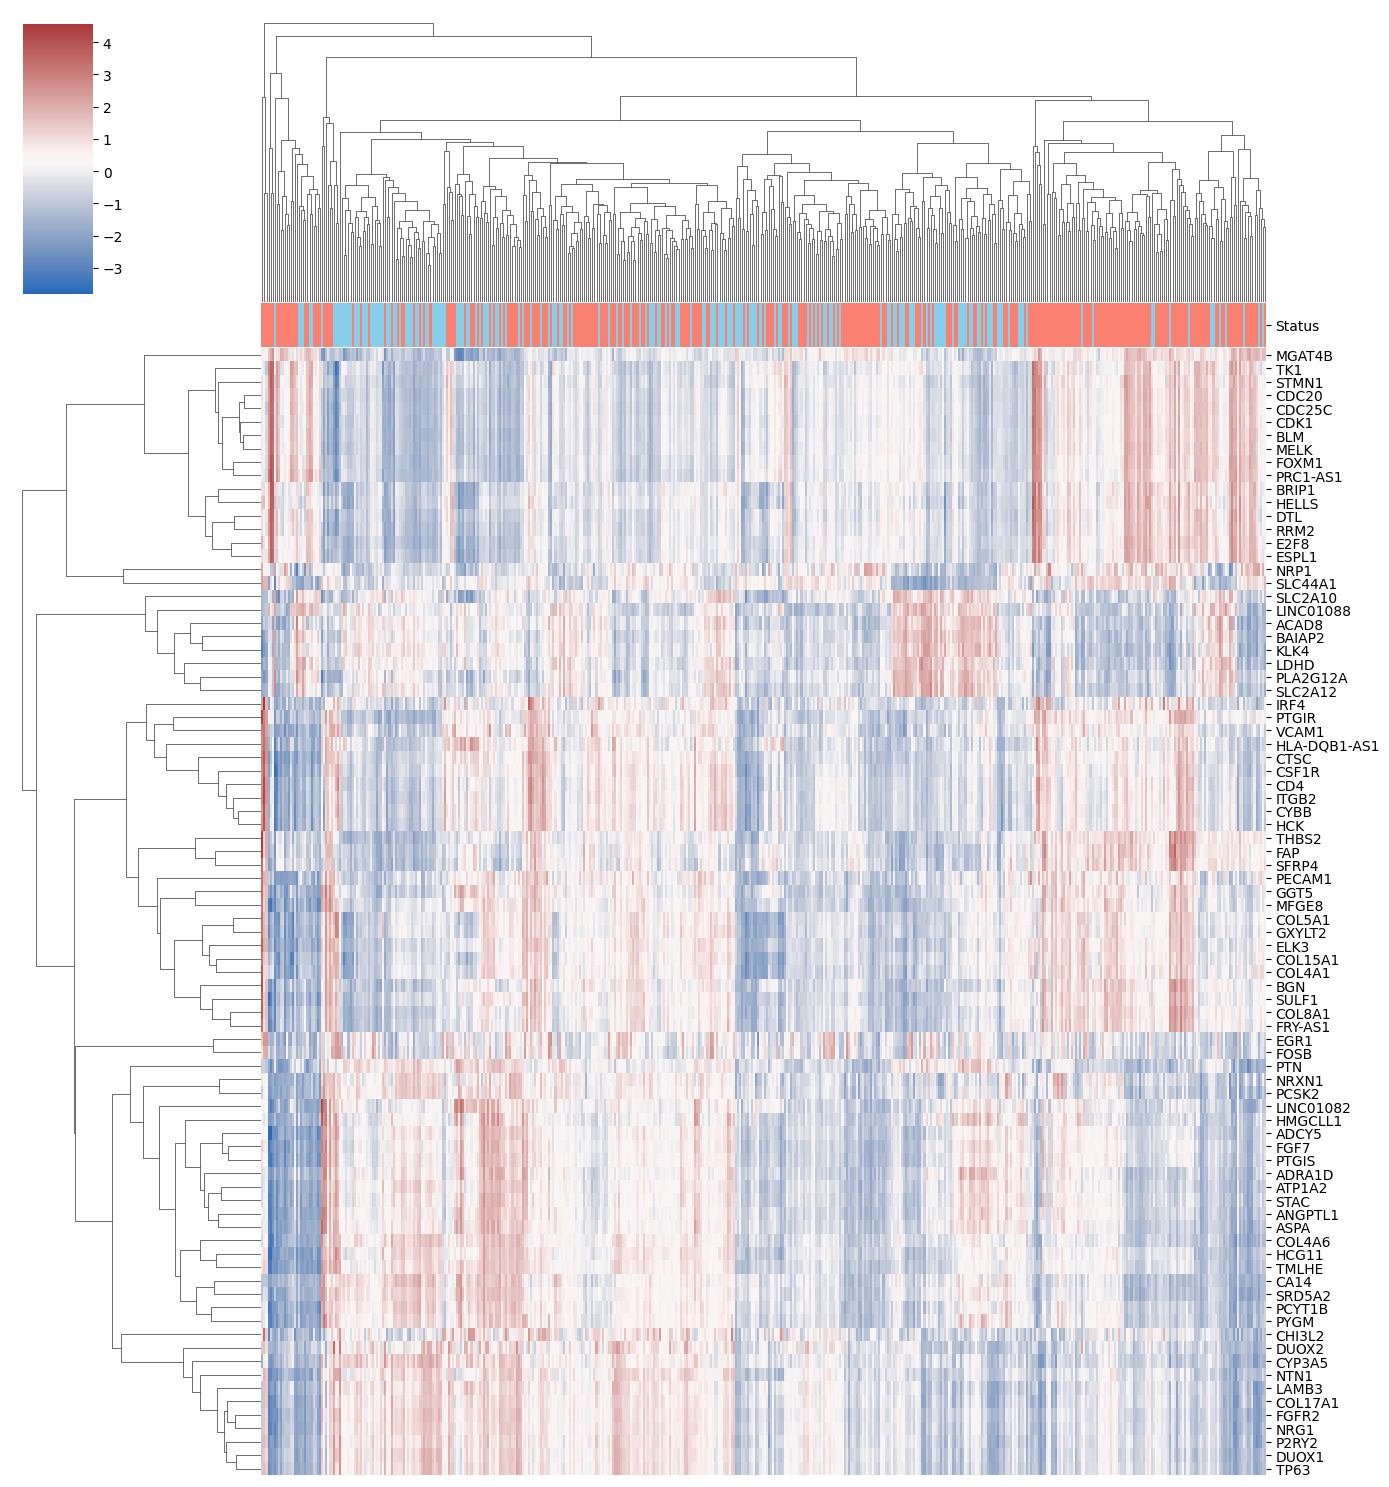

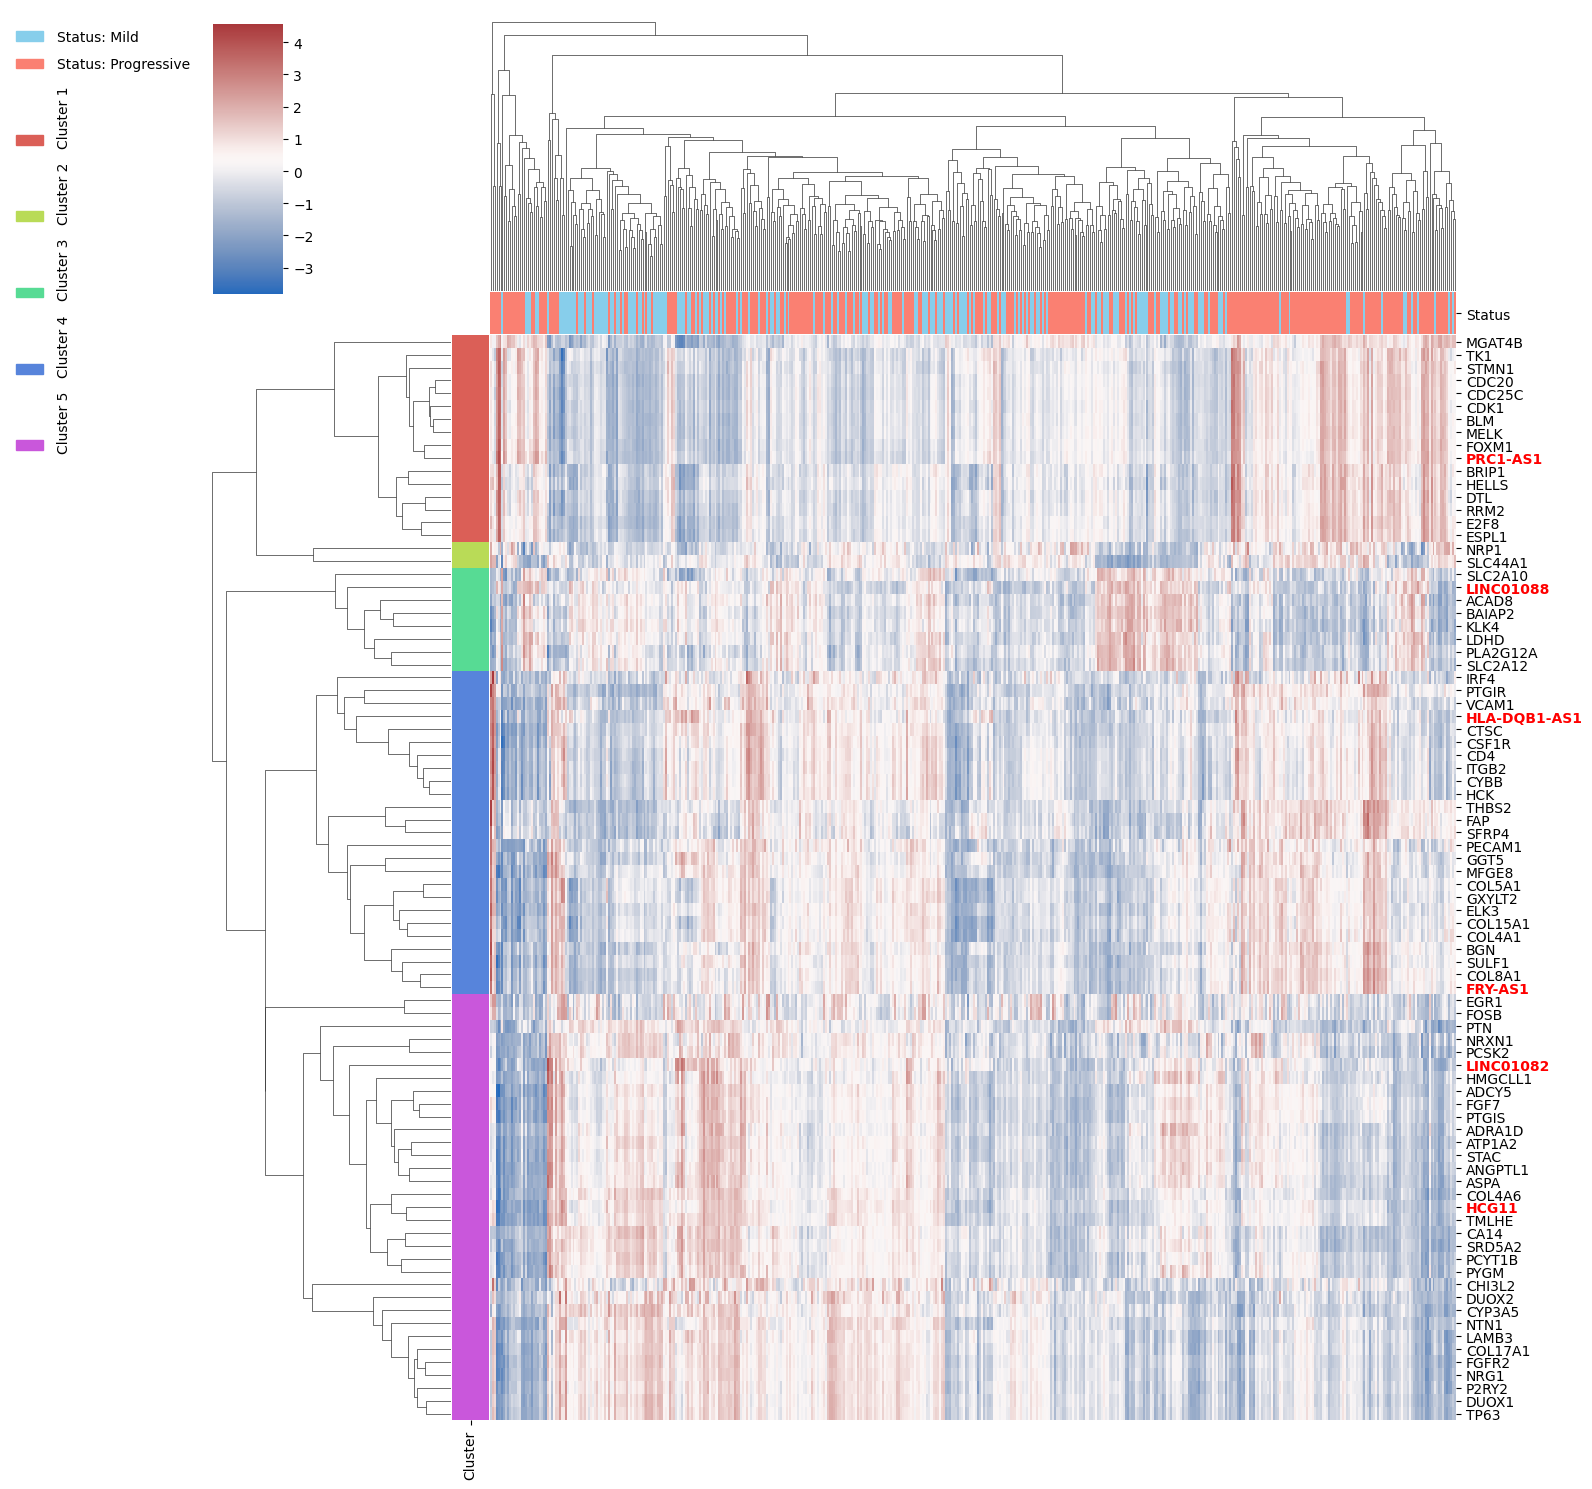

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import fcluster

# -----------------------------
# Load data
# -----------------------------
count_matrix = pd.read_csv("../../../data/TCGA/activity_ens.csv", index_col=0)
clinical = pd.read_excel("../../../data/TCGA/clinical_info.xlsx")

# Set Sample_ID as index
clinical = clinical.set_index('Sample_ID')

# Keep only samples present in both datasets
common_samples = count_matrix.columns.intersection(clinical.index)
count_matrix = count_matrix[common_samples]
clinical = clinical.loc[common_samples]

# -----------------------------
# Define genes of interest (Type == "NC")
# -----------------------------
genes_of_interest = res_tcga_filt[res_tcga_filt['Type'] == "NC"]['ID'].tolist()
count_matrix_subset = count_matrix.loc[count_matrix.index.intersection(res_tcga_filt['ID'].tolist())]

# -----------------------------
# Create color palette for Status annotation only
# -----------------------------
status_colors = {'Mild': 'skyblue', 'Progressive': 'salmon'}

# Map clinical annotations to colors (only Status)
col_colors = pd.DataFrame({
    'Status': clinical['Status'].map(status_colors)
})

# -----------------------------
# Cluster genes (rows)
# -----------------------------
k = 5  # number of row clusters

# Initial clustermap to extract row clusters
g = sns.clustermap(
    count_matrix_subset,
    cmap="vlag",
    z_score=0,
    row_cluster=True,
    col_cluster=True,
    col_colors=col_colors,
    xticklabels=False,
    yticklabels=True,
    figsize=(14, 15)
)

# Extract row clusters from dendrogram
row_linkage = g.dendrogram_row.linkage
row_clusters = fcluster(row_linkage, k, criterion='maxclust')

# Assign colors to clusters
cluster_palette = sns.color_palette("hls", k)
cluster_colors = {i: cluster_palette[i-1] for i in range(1, k+1)}
row_colors = pd.DataFrame({"Cluster": [cluster_colors[c] for c in row_clusters]}, index=count_matrix_subset.index)

# -----------------------------
# Map genes to clusters and save
# -----------------------------
gene_clusters = pd.DataFrame({
    'Gene': count_matrix_subset.index,
    'Cluster': row_clusters
})
gene_clusters.to_csv("../../figures/TCGA_gene_clusters.csv", index=False)

# Dictionary of genes per cluster
genes_per_cluster = {i: gene_clusters[gene_clusters['Cluster'] == i]['Gene'].tolist() for i in range(1, k+1)}

# Print clusters
for cluster_id, genes in genes_per_cluster.items():
    print(f"\nCluster {cluster_id} ({len(genes)} genes):")
    print(genes)

# -----------------------------
# Replot clustermap with row colors
# -----------------------------
g = sns.clustermap(
    count_matrix_subset,
    cmap="vlag",
    z_score=0,
    row_cluster=True,
    col_cluster=True,
    col_colors=col_colors,
    row_colors=row_colors,
    xticklabels=False,
    yticklabels=True,
    figsize=(14, 15)
)

# Highlight "NC" genes in RED
ax = g.ax_heatmap
for label in ax.get_yticklabels():
    if label.get_text() in genes_of_interest:
        label.set_color("red")
        label.set_fontweight("bold")

# -----------------------------
# Add legend (Status only)
# -----------------------------
legend_patches = [Patch(color=color, label=f"Status: {label}") for label, color in status_colors.items()]

# Add cluster legend with 90° labels
cluster_patches = [Patch(color=color, label=f"Cluster {i}") for i, color in cluster_colors.items()]

plt.legend(
    handles=legend_patches + cluster_patches,
    bbox_to_anchor=(-0.25, 1),
    loc='upper right',
    borderaxespad=0.,
    frameon=False,
    handletextpad=1,
    labelspacing=1
)

# Rotate cluster labels 90° in legend
for text in plt.gca().get_legend().get_texts():
    if "Cluster" in text.get_text():
        text.set_rotation(90)
        text.set_horizontalalignment('center')

# -----------------------------
# Save figure
# -----------------------------
g.fig.savefig("../../figures/TCGA_clustermap_highlightNC_clustered.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
## only lncRNAs


Cluster 1 (4 genes):
['FRY-AS1', 'HCG11', 'HLA-DQB1-AS1', 'LINC01082']

Cluster 2 (2 genes):
['LINC01088', 'PRC1-AS1']


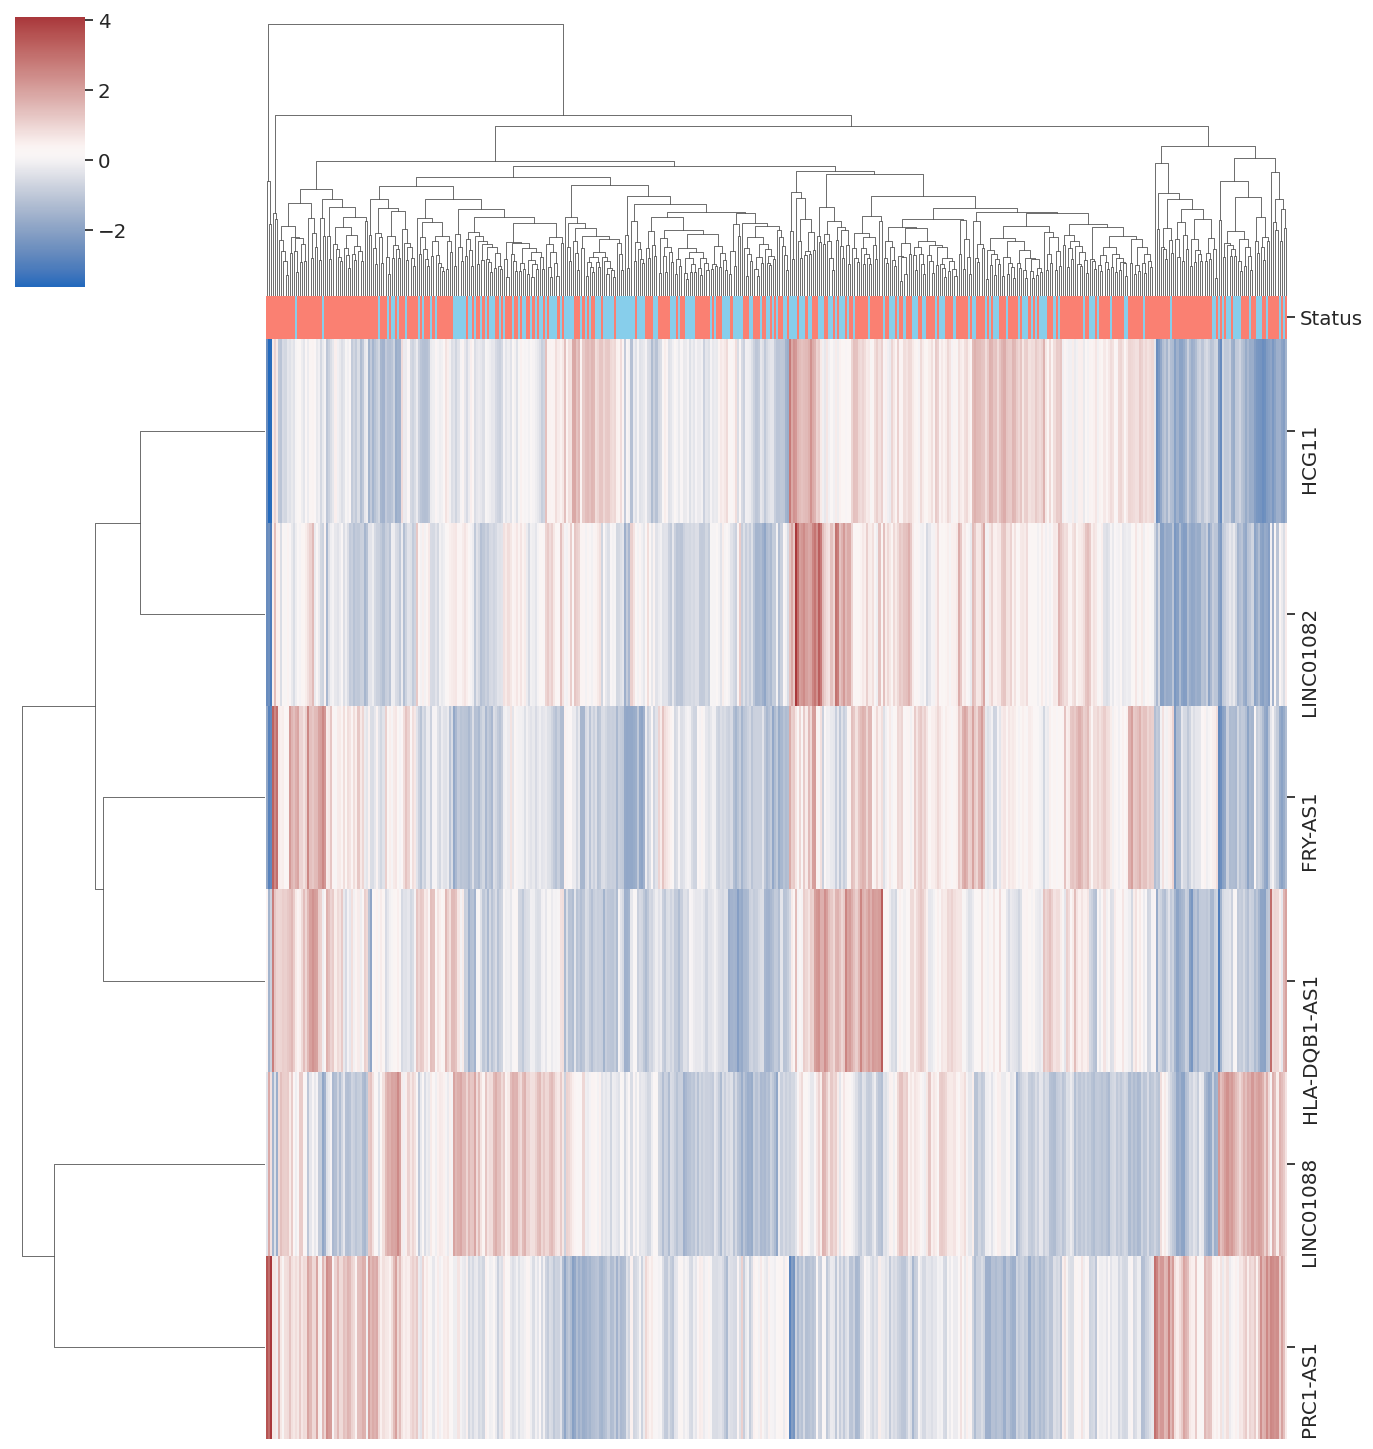

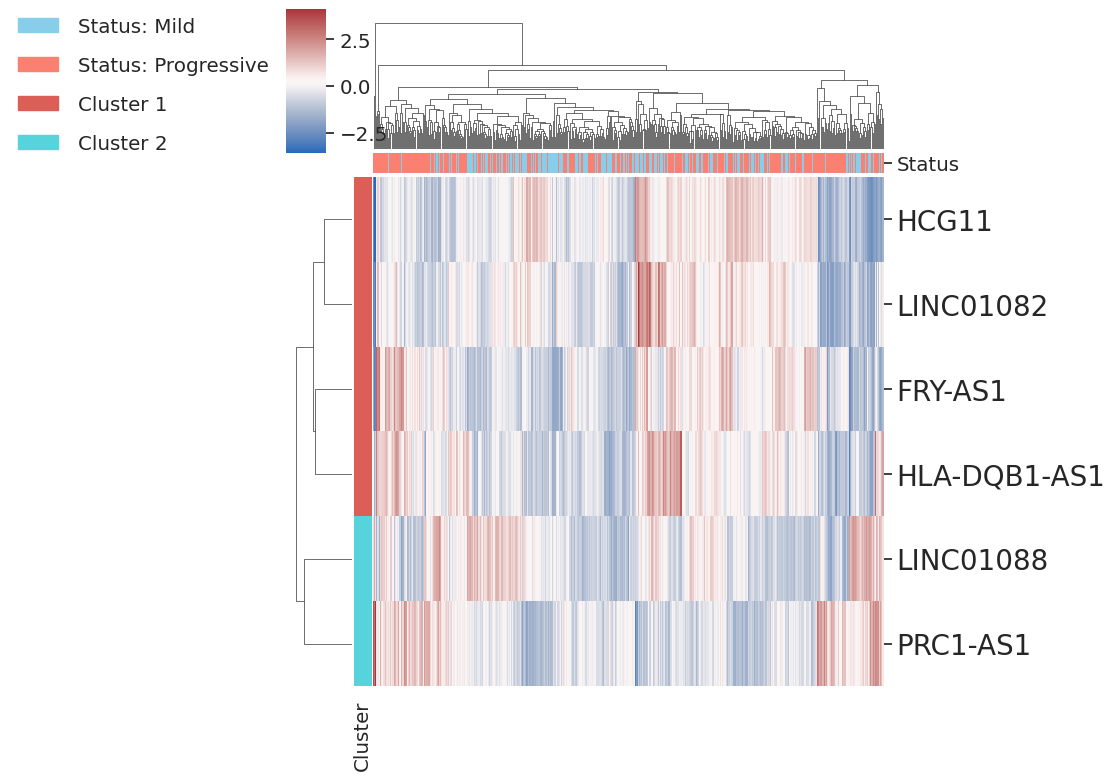

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import fcluster

# -----------------------------
# Load data
# -----------------------------
count_matrix = pd.read_csv("../../../data/TCGA/activity_ens.csv", index_col=0)
clinical = pd.read_excel("../../../data/TCGA/clinical_info.xlsx")

# Set Sample_ID as index
clinical = clinical.set_index('Sample_ID')

# Keep only samples present in both datasets
common_samples = count_matrix.columns.intersection(clinical.index)
count_matrix = count_matrix[common_samples]
clinical = clinical.loc[common_samples]

# -----------------------------
# Define genes of interest (Type == "NC")
# -----------------------------
# Make sure res_tcga_filt is loaded previously
# res_tcga_filt = pd.read_csv(...)

genes_of_interest = res_tcga_filt[res_tcga_filt['Type'] == "NC"]['ID'].tolist()
count_matrix_subset = count_matrix.loc[count_matrix.index.intersection(res_tcga_filt['ID'].tolist())]

# Subset to NC genes only
count_matrix_nc = count_matrix_subset.loc[count_matrix_subset.index.intersection(genes_of_interest)]

# -----------------------------
# Create color palette for Status annotation only
# -----------------------------
status_colors = {'Mild': 'skyblue', 'Progressive': 'salmon'}
col_colors = pd.DataFrame({
    'Status': clinical['Status'].map(status_colors)
})

# -----------------------------
# Cluster NC genes (rows)
# -----------------------------
k_nc = 2  # number of row clusters

# Initial clustermap to extract row clusters
g_nc = sns.clustermap(
    count_matrix_nc,
    cmap="vlag",
    z_score=0,
    row_cluster=True,
    col_cluster=True,
    col_colors=col_colors,
    xticklabels=False,
    yticklabels=True,
    figsize=(14, 15)
)

# Extract row clusters from dendrogram
row_linkage_nc = g_nc.dendrogram_row.linkage
row_clusters_nc = fcluster(row_linkage_nc, k_nc, criterion='maxclust')

# Assign colors to clusters
cluster_palette_nc = sns.color_palette("hls", k_nc)
cluster_colors_nc = {i: cluster_palette_nc[i-1] for i in range(1, k_nc+1)}
row_colors_nc = pd.DataFrame({"Cluster": [cluster_colors_nc[c] for c in row_clusters_nc]}, index=count_matrix_nc.index)

# -----------------------------
# Map genes to clusters and save
# -----------------------------
gene_clusters_nc = pd.DataFrame({
    'Gene': count_matrix_nc.index,
    'Cluster': row_clusters_nc
})
gene_clusters_nc.to_csv("../../figures/TCGA_gene_clusters_NC_only.csv", index=False)

genes_per_cluster_nc = {i: gene_clusters_nc[gene_clusters_nc['Cluster'] == i]['Gene'].tolist() for i in range(1, k_nc+1)}
for cluster_id, genes in genes_per_cluster_nc.items():
    print(f"\nCluster {cluster_id} ({len(genes)} genes):")
    print(genes)

# -----------------------------
# Replot clustermap with row colors and better labels
# -----------------------------
sns.set(font_scale=1.3)  # globally scale up all text (works better than setting individually)

g_nc = sns.clustermap(
    count_matrix_nc,
    cmap="vlag",
    z_score=0,
    row_cluster=True,
    col_cluster=True,
    col_colors=col_colors,
    row_colors=row_colors_nc,
    xticklabels=False,
    yticklabels=True,
    figsize=(8, 8),
    dendrogram_ratio=(.1, .2),
    cbar_pos=(0.02, 0.8, 0.05, 0.18)
)

# Fine-tune y-axis label font size and rotation
plt.setp(g_nc.ax_heatmap.get_yticklabels(), fontsize=20, rotation=0)  # increase size and keep horizontal

# -----------------------------
# Add legend (Status + Cluster)
# -----------------------------
legend_patches = [Patch(color=color, label=f"Status: {label}") for label, color in status_colors.items()]
cluster_patches = [Patch(color=color, label=f"Cluster {i}") for i, color in cluster_colors_nc.items()]

legend = plt.legend(
    handles=legend_patches + cluster_patches,
    bbox_to_anchor=(-0.25, 1),
    loc='upper right',
    borderaxespad=0.,
    frameon=False,
    handletextpad=1,
    labelspacing=1
)

# Keep cluster text horizontal
for text in legend.get_texts():
    text.set_rotation(0)
    text.set_horizontalalignment('left')

# -----------------------------
# Save figure
# -----------------------------
g_nc.fig.savefig("../../figures/TCGA_clustermap_onlyNC.png", dpi=300, bbox_inches="tight")
plt.show()



Cluster 1 (16 genes):
['BLM', 'BRIP1', 'CDC20', 'CDC25C', 'CDK1', 'DTL', 'E2F8', 'ESPL1', 'FOXM1', 'HELLS', 'MELK', 'MGAT4B', 'PRC1-AS1', 'RRM2', 'STMN1', 'TK1']

Cluster 2 (2 genes):
['NRP1', 'SLC44A1']

Cluster 3 (8 genes):
['ACAD8', 'BAIAP2', 'KLK4', 'LDHD', 'LINC01088', 'PLA2G12A', 'SLC2A10', 'SLC2A12']

Cluster 4 (58 genes):
['ADCY5', 'ADRA1D', 'ANGPTL1', 'ASPA', 'ATP1A2', 'BGN', 'CA14', 'CD4', 'CHI3L2', 'COL15A1', 'COL17A1', 'COL4A1', 'COL4A6', 'COL5A1', 'COL8A1', 'CSF1R', 'CTSC', 'CYBB', 'CYP3A5', 'DUOX1', 'DUOX2', 'EGR1', 'ELK3', 'FAP', 'FGF7', 'FGFR2', 'FOSB', 'FRY-AS1', 'GGT5', 'GXYLT2', 'HCG11', 'HCK', 'HLA-DQB1-AS1', 'HMGCLL1', 'IRF4', 'ITGB2', 'LAMB3', 'LINC01082', 'MFGE8', 'NRG1', 'NRXN1', 'NTN1', 'P2RY2', 'PCSK2', 'PCYT1B', 'PECAM1', 'PTGIR', 'PTGIS', 'PTN', 'PYGM', 'SFRP4', 'SRD5A2', 'STAC', 'SULF1', 'THBS2', 'TMLHE', 'TP63', 'VCAM1']


/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


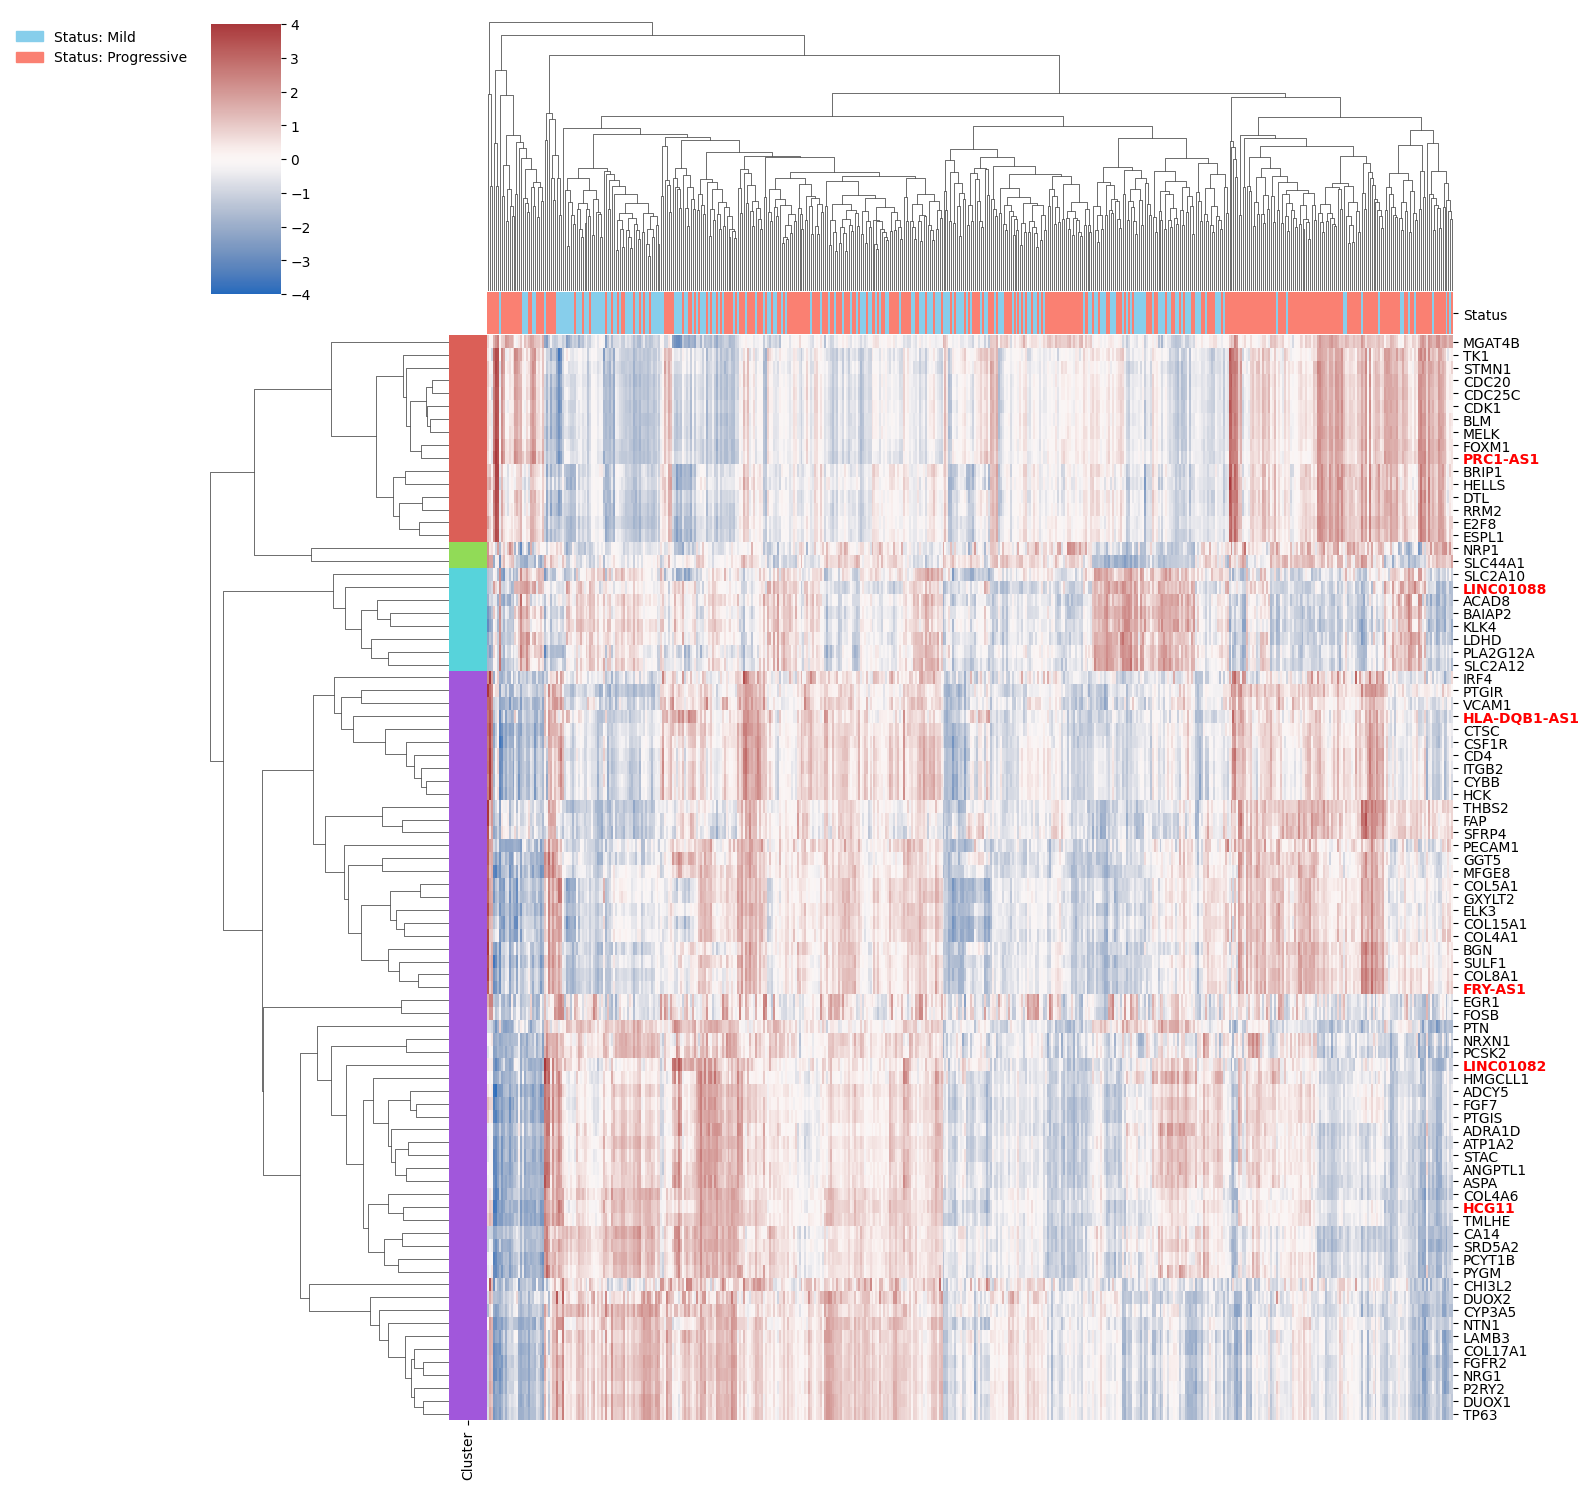

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import fcluster

# -----------------------------
# Load data
# -----------------------------
count_matrix = pd.read_csv("../../../data/TCGA/activity_ens.csv", index_col=0)
clinical = pd.read_excel("../../../data/TCGA/clinical_info.xlsx")

# Set Sample_ID as index
clinical = clinical.set_index('Sample_ID')

# Keep only samples present in both datasets
common_samples = count_matrix.columns.intersection(clinical.index)
count_matrix = count_matrix[common_samples]
clinical = clinical.loc[common_samples]

# -----------------------------
# Define genes of interest (Type == "NC")
# -----------------------------
# Make sure res_tcga_filt is defined before running this
genes_of_interest = res_tcga_filt[res_tcga_filt['Type'] == "NC"]['ID'].tolist()
count_matrix_subset = count_matrix.loc[
    count_matrix.index.intersection(res_tcga_filt['ID'].tolist())
]

# -----------------------------
# Create color palette for Status annotation only
# -----------------------------
status_colors = {'Mild': 'skyblue', 'Progressive': 'salmon'}

# Map Status annotation to colors
col_colors = pd.DataFrame({
    'Status': clinical['Status'].map(status_colors)
})

# -----------------------------
# Cluster genes (rows)
# -----------------------------
k = 4  # number of row clusters

# Create the initial clustermap
#g = sns.clustermap(
#    count_matrix_subset,
#    cmap="vlag",
#    z_score=0,
#    row_cluster=True,
#    col_cluster=True,
#    col_colors=col_colors,
#    xticklabels=False,
#    yticklabels=True,
#    figsize=(14, 15)
#)

# Extract row clusters from dendrogram
row_linkage = g.dendrogram_row.linkage
row_clusters = fcluster(row_linkage, k, criterion='maxclust')

# Assign colors to clusters
cluster_palette = sns.color_palette("hls", k)
cluster_colors = {i: cluster_palette[i-1] for i in range(1, k+1)}
row_colors = pd.DataFrame(
    {"Cluster": [cluster_colors[c] for c in row_clusters]},
    index=count_matrix_subset.index
)

# -----------------------------
# Map genes to clusters and save
# -----------------------------
gene_clusters = pd.DataFrame({
    'Gene': count_matrix_subset.index,
    'Cluster': row_clusters
})
gene_clusters.to_csv("../../figures/TCGA_gene_clusters_heatmap.csv", index=False)

# Dictionary of genes per cluster
genes_per_cluster = {
    i: gene_clusters[gene_clusters['Cluster'] == i]['Gene'].tolist()
    for i in range(1, k+1)
}

# Print clusters
for cluster_id, genes in genes_per_cluster.items():
    print(f"\nCluster {cluster_id} ({len(genes)} genes):")
    print(genes)

# -----------------------------
# Replot with row_colors
# -----------------------------
g = sns.clustermap(
    count_matrix_subset,
    cmap="vlag",
    z_score=0,
    row_cluster=True,
    col_cluster=True,
    col_colors=col_colors,
    row_colors=row_colors,
    xticklabels=False,
    yticklabels=True,
    figsize=(14, 15),
    vmin=-4,               # set min color to -1
    vmax=4                 # set max color to 1
)

# Highlight "NC" genes in RED
ax = g.ax_heatmap
for label in ax.get_yticklabels():
    if label.get_text() in genes_of_interest:
        label.set_color("red")
        label.set_fontweight("bold")

# -----------------------------
# Add legend (Status only)
# -----------------------------
legend_patches = [
    Patch(color=color, label=f"Status: {label}")
    for label, color in status_colors.items()
]

plt.legend(
    handles=legend_patches,
    bbox_to_anchor=(-0.25, 1),
    loc='upper right',
    borderaxespad=0.,
    frameon=False
)

# -----------------------------
# Save figure
# -----------------------------
g.fig.savefig(
    "../../figures/TCGA_clustermap_highlightNC_clustered.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


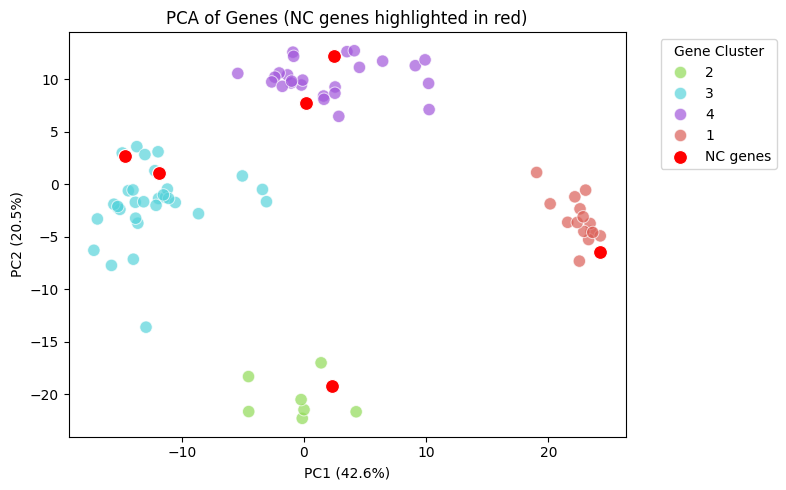

In [61]:
# -----------------------------
# Imports
# -----------------------------
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.decomposition import PCA
import seaborn as sns

# -----------------------------
# Load data
# -----------------------------
count_matrix = pd.read_csv("../../../data/TCGA/activity_ens.csv", index_col=0)
clinical = pd.read_excel("../../../data/TCGA/clinical_info.xlsx").set_index('Sample_ID')

# Keep only samples present in both datasets
common_samples = count_matrix.columns.intersection(clinical.index)
count_matrix = count_matrix[common_samples]
clinical = clinical.loc[common_samples]

# -----------------------------
# Use all genes from res_tcga_filt
# -----------------------------
genes_of_interest = res_tcga_filt['ID'].tolist()
count_matrix_subset = count_matrix.loc[count_matrix.index.intersection(genes_of_interest)]

# Identify NC genes
nc_genes = res_tcga_filt[res_tcga_filt['Type'] == "NC"]['ID'].tolist()

# -----------------------------
# Cluster genes (rows)
# -----------------------------
k = 4  # number of gene clusters
row_linkage = linkage(count_matrix_subset, method='average', metric='correlation')
row_clusters = fcluster(row_linkage, k, criterion='maxclust')

# Map cluster colors (keys as strings for Seaborn)
cluster_palette = sns.color_palette("hls", k)
cluster_colors_str = {str(i): cluster_palette[i-1] for i in range(1, k+1)}

# -----------------------------
# PCA (genes as points)
# -----------------------------
X = count_matrix_subset
# Z-score per gene
X_scaled = (X - X.mean(axis=1).values.reshape(-1,1)) / X.std(axis=1).values.reshape(-1,1)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(pca_result, index=X.index, columns=['PC1', 'PC2'])
pca_df['Cluster'] = row_clusters.astype(str)
pca_df['NC'] = [gene in nc_genes for gene in X.index]

# -----------------------------
# Plot PCA without labels
# -----------------------------
plt.figure(figsize=(8,5))

# Plot non-NC genes colored by cluster
sns.scatterplot(
    data=pca_df[~pca_df['NC']],
    x='PC1', y='PC2',
    hue='Cluster',
    palette=cluster_colors_str,
    s=80,
    alpha=0.7,
    legend='full'
)

# Plot NC genes in red
sns.scatterplot(
    data=pca_df[pca_df['NC']],
    x='PC1', y='PC2',
    color='red',
    s=100,
    label='NC genes'
)

plt.title("PCA of Genes (NC genes highlighted in red)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(title='Gene Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


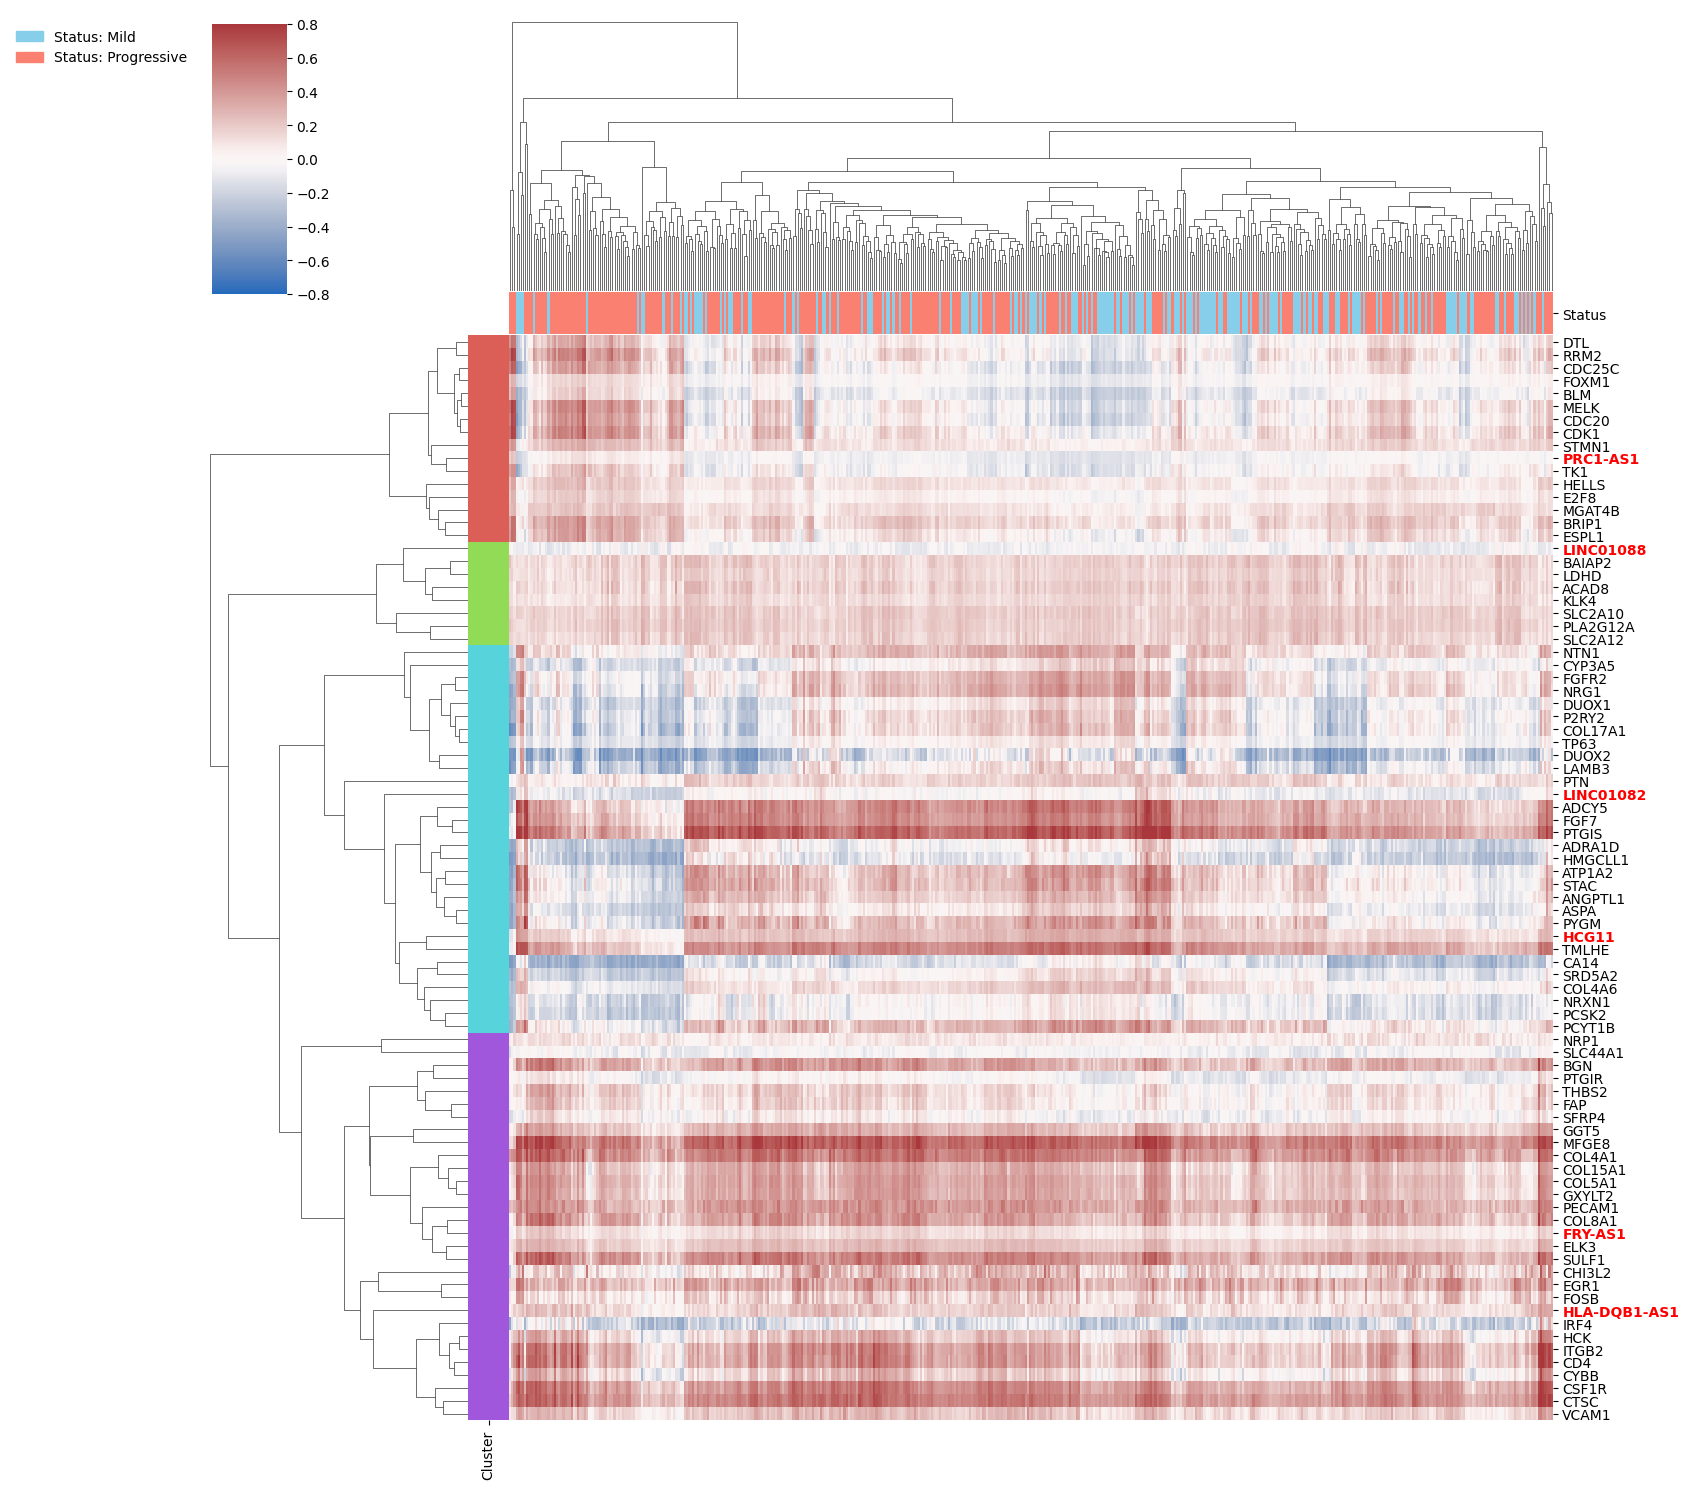

In [67]:
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, fcluster
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -----------------------------
# Subset genes of interest
# -----------------------------
genes_of_interest = res_tcga_filt['ID'].tolist()
count_matrix_subset = count_matrix.loc[count_matrix.index.intersection(genes_of_interest)]
nc_genes = res_tcga_filt[res_tcga_filt['Type'] == "NC"]['ID'].tolist()

# -----------------------------
# PCA on genes (rows as samples)
# -----------------------------
X = count_matrix_subset

# Z-score per gene for PCA only
X_scaled = (X - X.mean(axis=1).values.reshape(-1,1)) / X.std(axis=1).values.reshape(-1,1)

pca = PCA(n_components=5)
pca_result = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(pca_result, index=X.index)

# -----------------------------
# Cluster genes based on PCA coordinates
# -----------------------------
k = 4
row_linkage = linkage(pca_df, method='average', metric='euclidean')
row_clusters = fcluster(row_linkage, k, criterion='maxclust')

# Cluster colors
cluster_palette = sns.color_palette("hls", k)
row_colors = pd.DataFrame({
    "Cluster": [cluster_palette[c-1] for c in row_clusters]
}, index=count_matrix_subset.index)

# -----------------------------
# Status colors
# -----------------------------
status_colors = {'Mild': 'skyblue', 'Progressive': 'salmon'}
col_colors = pd.DataFrame({'Status': clinical['Status'].map(status_colors)})

# -----------------------------
# Plot heatmap with raw counts
# -----------------------------
g = sns.clustermap(
    count_matrix_subset,  # raw counts
    cmap="vlag",
    row_cluster=True,
    col_cluster=True,
    row_linkage=row_linkage,  # PCA-based clustering
    col_colors=col_colors,
    row_colors=row_colors,
    xticklabels=False,
    yticklabels=True,
    figsize=(15, 15),
    vmin=-0.8,               # set min color to -1
    vmax=0.8                 # set max color to 1
)

# Highlight NC genes in red
ax = g.ax_heatmap
for label in ax.get_yticklabels():
    if label.get_text() in nc_genes:
        label.set_color("red")
        label.set_fontweight("bold")

# Legend for Status
legend_patches = [Patch(color=color, label=f"Status: {label}") for label, color in status_colors.items()]
plt.legend(
    handles=legend_patches,
    bbox_to_anchor=(-0.25, 1),
    loc='upper right',
    borderaxespad=0.,
    frameon=False
)

plt.show()


In [ ]:
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, fcluster
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -----------------------------
# Subset genes of interest
# -----------------------------
genes_of_interest = res_tcga_filt['ID'].tolist()
count_matrix_subset = count_matrix.loc[count_matrix.index.intersection(genes_of_interest)]
nc_genes = res_tcga_filt[res_tcga_filt['Type'] == "NC"]['ID'].tolist()

# -----------------------------
# PCA on genes (rows as samples)
# -----------------------------
X = count_matrix_subset

# Z-score per gene for PCA only
X_scaled = (X - X.mean(axis=1).values.reshape(-1,1)) / X.std(axis=1).values.reshape(-1,1)

pca = PCA(n_components=5)
pca_result = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(pca_result, index=X.index)

# -----------------------------
# Cluster genes based on PCA coordinates
# -----------------------------
k = 4
row_linkage = linkage(pca_df, method='average', metric='euclidean')
row_clusters = fcluster(row_linkage, k, criterion='maxclust')

# Cluster colors
cluster_palette = sns.color_palette("hls", k)
row_colors = pd.DataFrame({
    "Cluster": [cluster_palette[c-1] for c in row_clusters]
}, index=count_matrix_subset.index)

# -----------------------------
# Status colors
# -----------------------------
status_colors = {'Mild': 'skyblue', 'Progressive': 'salmon'}
col_colors = pd.DataFrame({'Status': clinical['Status'].map(status_colors)})

# -----------------------------
# Plot heatmap with raw counts
# -----------------------------
g = sns.clustermap(
    count_matrix_subset,  # raw counts
    cmap="vlag",
    row_cluster=True,
    col_cluster=True,
    row_linkage=row_linkage,  # PCA-based clustering
    col_colors=col_colors,
    row_colors=row_colors,
    xticklabels=False,
    yticklabels=True,
    figsize=(15, 15),
    vmin=-0.8,               # set min color to -1
    vmax=0.8                 # set max color to 1
)

# Highlight NC genes in red
ax = g.ax_heatmap
for label in ax.get_yticklabels():
    if label.get_text() in nc_genes:
        label.set_color("red")
        label.set_fontweight("bold")

# Legend for Status
legend_patches = [Patch(color=color, label=f"Status: {label}") for label, color in status_colors.items()]
plt.legend(
    handles=legend_patches,
    bbox_to_anchor=(-0.25, 1),
    loc='upper right',
    borderaxespad=0.,
    frameon=False
)

plt.show()


/tmp/ipykernel_1275/1110134237.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res_tcga_filt['ID'] = res_tcga_filt['ID'].str.replace(r'\.\d+$', '', regex=True)
/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


✅ Subset created: 84 genes × 490 samples

Cluster 1 (16 genes):
['FOXM1', 'CDC20', 'STMN1', 'HELLS', 'E2F8', 'ESPL1', 'BRIP1', 'DTL', 'CDC25C', 'MGAT4B', 'MELK', 'TK1', 'CDK1', 'RRM2', 'BLM', 'PRC1-AS1']

Cluster 2 (8 genes):
['PLA2G12A', 'SLC2A12', 'ACAD8', 'LDHD', 'KLK4', 'BAIAP2', 'SLC2A10', 'LINC01088']

Cluster 3 (27 genes):
['CD4', 'SLC44A1', 'FAP', 'NRP1', 'GGT5', 'HCK', 'SFRP4', 'CTSC', 'ELK3', 'COL5A1', 'IRF4', 'SULF1', 'MFGE8', 'COL8A1', 'PTGIR', 'ITGB2', 'VCAM1', 'CYBB', 'GXYLT2', 'BGN', 'CSF1R', 'THBS2', 'COL4A1', 'COL15A1', 'HLA-DQB1-AS1', 'FRY-AS1', 'PECAM1']

Cluster 4 (33 genes):
['ATP1A2', 'CHI3L2', 'NTN1', 'COL17A1', 'FGFR2', 'PYGM', 'TP63', 'PCYT1B', 'PTN', 'CYP3A5', 'ASPA', 'ANGPTL1', 'CA14', 'EGR1', 'PTGIS', 'FOSB', 'PCSK2', 'DUOX1', 'DUOX2', 'FGF7', 'STAC', 'HMGCLL1', 'NRG1', 'ADRA1D', 'ADCY5', 'P2RY2', 'NRXN1', 'TMLHE', 'LAMB3', 'COL4A6', 'HCG11', 'LINC01082', 'SRD5A2']


/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


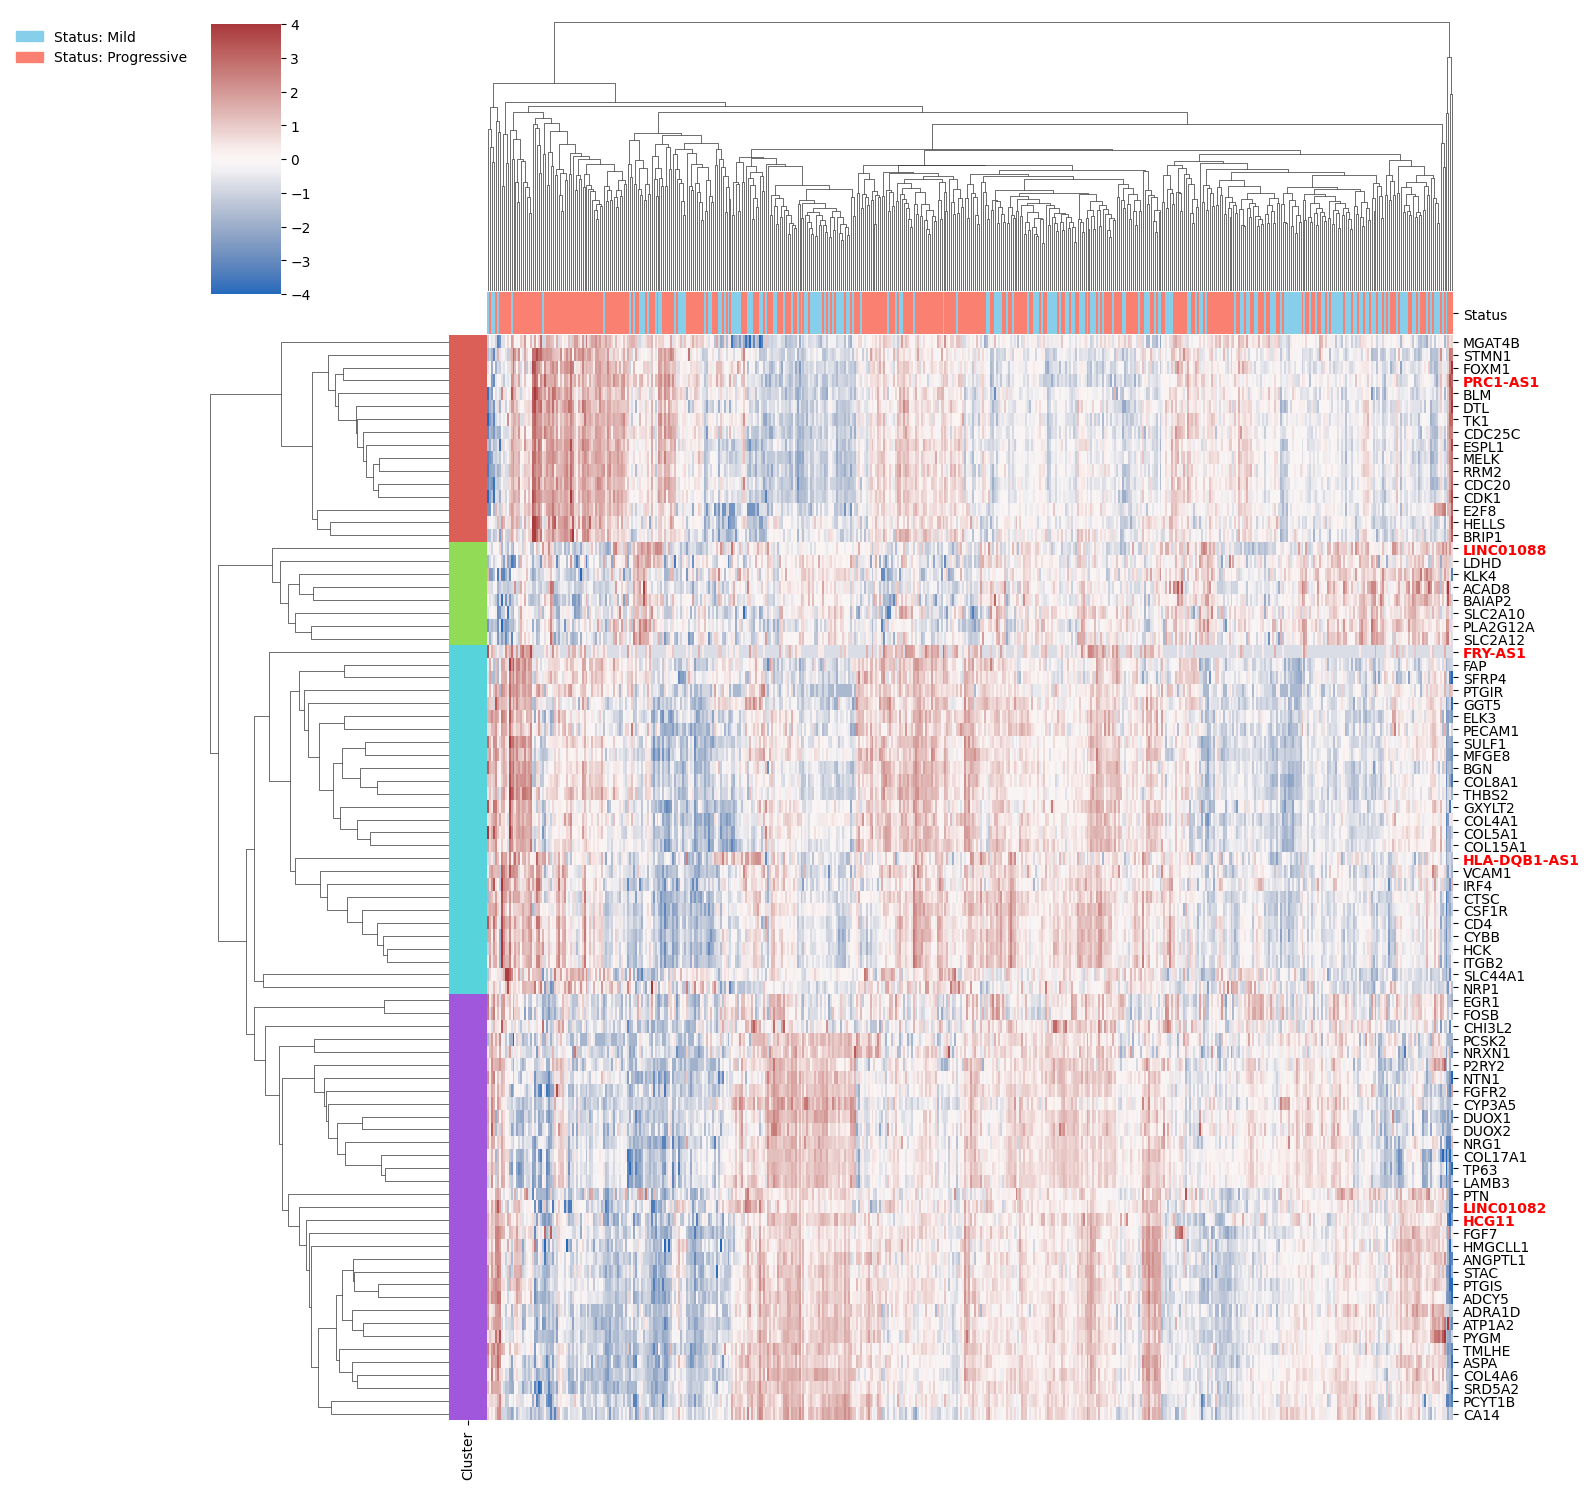


✅ Clustermap saved to: ../../figures/TCGA_clustermap_highlightNC_clustered_expression.png


In [78]:
# ============================================================
# TCGA Heatmap with Clustering and "NC" Gene Highlighting
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import fcluster

# -----------------------------
# Load data
# -----------------------------
count_matrix = pd.read_csv("../../../data/TCGA/count_matrix.csv", index_col=0)
clinical = pd.read_excel("../../../data/TCGA/clinical_info.xlsx")

# Set Sample_ID as index
clinical = clinical.set_index('Sample_ID')

# Keep only samples present in both datasets
common_samples = count_matrix.columns.intersection(clinical.index)
count_matrix = count_matrix[common_samples]
clinical = clinical.loc[common_samples]

# -----------------------------
# Prepare res_tcga_filt and gene list
# -----------------------------
# Ensure res_tcga_filt is defined before this script
# It should have columns: ['ID', 'Type']

# Clean Ensembl IDs (remove version numbers if present)
count_matrix.index = count_matrix.index.str.replace(r'\.\d+$', '', regex=True)
if 'ID' in res_tcga_filt.columns:
    res_tcga_filt['ID'] = res_tcga_filt['ID'].str.replace(r'\.\d+$', '', regex=True)

# Define genes of interest (Type == "NC")
genes_of_interest = res_tcga_filt.loc[res_tcga_filt['Type'] == "NC", 'ID'].tolist()

# Subset count matrix to only include relevant genes
valid_genes = count_matrix.index.intersection(res_tcga_filt['ID'].tolist())
count_matrix_subset = count_matrix.loc[valid_genes]

# Check for empty subset
if count_matrix_subset.empty:
    raise ValueError(
        "❌ count_matrix_subset is empty — check that gene IDs in count_matrix "
        "and res_tcga_filt['ID'] use the same format (e.g., remove version numbers)."
    )

print(f"✅ Subset created: {count_matrix_subset.shape[0]} genes × {count_matrix_subset.shape[1]} samples")

# -----------------------------
# Create color palette for Status annotation only
# -----------------------------
status_colors = {'Mild': 'skyblue', 'Progressive': 'salmon'}
col_colors = pd.DataFrame({
    'Status': clinical['Status'].map(status_colors)
})

# -----------------------------
# Cluster genes (rows)
# -----------------------------
k = 4  # number of row clusters

# Create initial clustermap (for row linkage extraction)
g_tmp = sns.clustermap(
    count_matrix_subset,
    cmap="vlag",
    z_score=0,
    row_cluster=True,
    col_cluster=True,
    xticklabels=False,
    yticklabels=False,
    figsize=(10, 10)
)
row_linkage = g_tmp.dendrogram_row.linkage
plt.close(g_tmp.fig)  # close temporary plot

# Extract row clusters
row_clusters = fcluster(row_linkage, k, criterion='maxclust')

# Assign colors to clusters
cluster_palette = sns.color_palette("hls", k)
cluster_colors = {i: cluster_palette[i-1] for i in range(1, k+1)}
row_colors = pd.DataFrame(
    {"Cluster": [cluster_colors[c] for c in row_clusters]},
    index=count_matrix_subset.index
)

# -----------------------------
# Map genes to clusters and save
# -----------------------------
gene_clusters = pd.DataFrame({
    'Gene': count_matrix_subset.index,
    'Cluster': row_clusters
})
gene_clusters.to_csv("../../figures/TCGA_gene_clusters_heatmap.csv", index=False)

# Dictionary of genes per cluster
genes_per_cluster = {
    i: gene_clusters[gene_clusters['Cluster'] == i]['Gene'].tolist()
    for i in range(1, k + 1)
}

# Print clusters summary
for cluster_id, genes in genes_per_cluster.items():
    print(f"\nCluster {cluster_id} ({len(genes)} genes):")
    print(genes)

# -----------------------------
# Final clustered heatmap with row_colors
# -----------------------------
g = sns.clustermap(
    count_matrix_subset,
    cmap="vlag",
    z_score=0,
    row_cluster=True,
    col_cluster=True,
    col_colors=col_colors,
    row_colors=row_colors,
    xticklabels=False,
    yticklabels=True,
    figsize=(14, 15),
    vmin=-4,
    vmax=4
)

# Highlight "NC" genes in red
ax = g.ax_heatmap
for label in ax.get_yticklabels():
    if label.get_text() in genes_of_interest:
        label.set_color("red")
        label.set_fontweight("bold")

# -----------------------------
# Add legend (Status only)
# -----------------------------
legend_patches = [
    Patch(color=color, label=f"Status: {label}")
    for label, color in status_colors.items()
]

plt.legend(
    handles=legend_patches,
    bbox_to_anchor=(-0.25, 1),
    loc='upper right',
    borderaxespad=0.,
    frameon=False
)

# -----------------------------
# Save final figure
# -----------------------------
output_path = "../../figures/TCGA_clustermap_highlightNC_clustered_expression.png"
g.fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n✅ Clustermap saved to: {output_path}")


/tmp/ipykernel_1275/3583881211.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res_tcga_filt['ID'] = res_tcga_filt['ID'].str.replace(r'\.\d+$', '', regex=True)
/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


✅ Subset created: 84 genes × 490 samples

Cluster 1 (16 genes):
['BLM', 'BRIP1', 'CDC20', 'CDC25C', 'CDK1', 'DTL', 'E2F8', 'ESPL1', 'FOXM1', 'HELLS', 'MELK', 'MGAT4B', 'PRC1-AS1', 'RRM2', 'STMN1', 'TK1']

Cluster 2 (2 genes):
['NRP1', 'SLC44A1']

Cluster 3 (8 genes):
['ACAD8', 'BAIAP2', 'KLK4', 'LDHD', 'LINC01088', 'PLA2G12A', 'SLC2A10', 'SLC2A12']

Cluster 4 (58 genes):
['ADCY5', 'ADRA1D', 'ANGPTL1', 'ASPA', 'ATP1A2', 'BGN', 'CA14', 'CD4', 'CHI3L2', 'COL15A1', 'COL17A1', 'COL4A1', 'COL4A6', 'COL5A1', 'COL8A1', 'CSF1R', 'CTSC', 'CYBB', 'CYP3A5', 'DUOX1', 'DUOX2', 'EGR1', 'ELK3', 'FAP', 'FGF7', 'FGFR2', 'FOSB', 'FRY-AS1', 'GGT5', 'GXYLT2', 'HCG11', 'HCK', 'HLA-DQB1-AS1', 'HMGCLL1', 'IRF4', 'ITGB2', 'LAMB3', 'LINC01082', 'MFGE8', 'NRG1', 'NRXN1', 'NTN1', 'P2RY2', 'PCSK2', 'PCYT1B', 'PECAM1', 'PTGIR', 'PTGIS', 'PTN', 'PYGM', 'SFRP4', 'SRD5A2', 'STAC', 'SULF1', 'THBS2', 'TMLHE', 'TP63', 'VCAM1']


/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


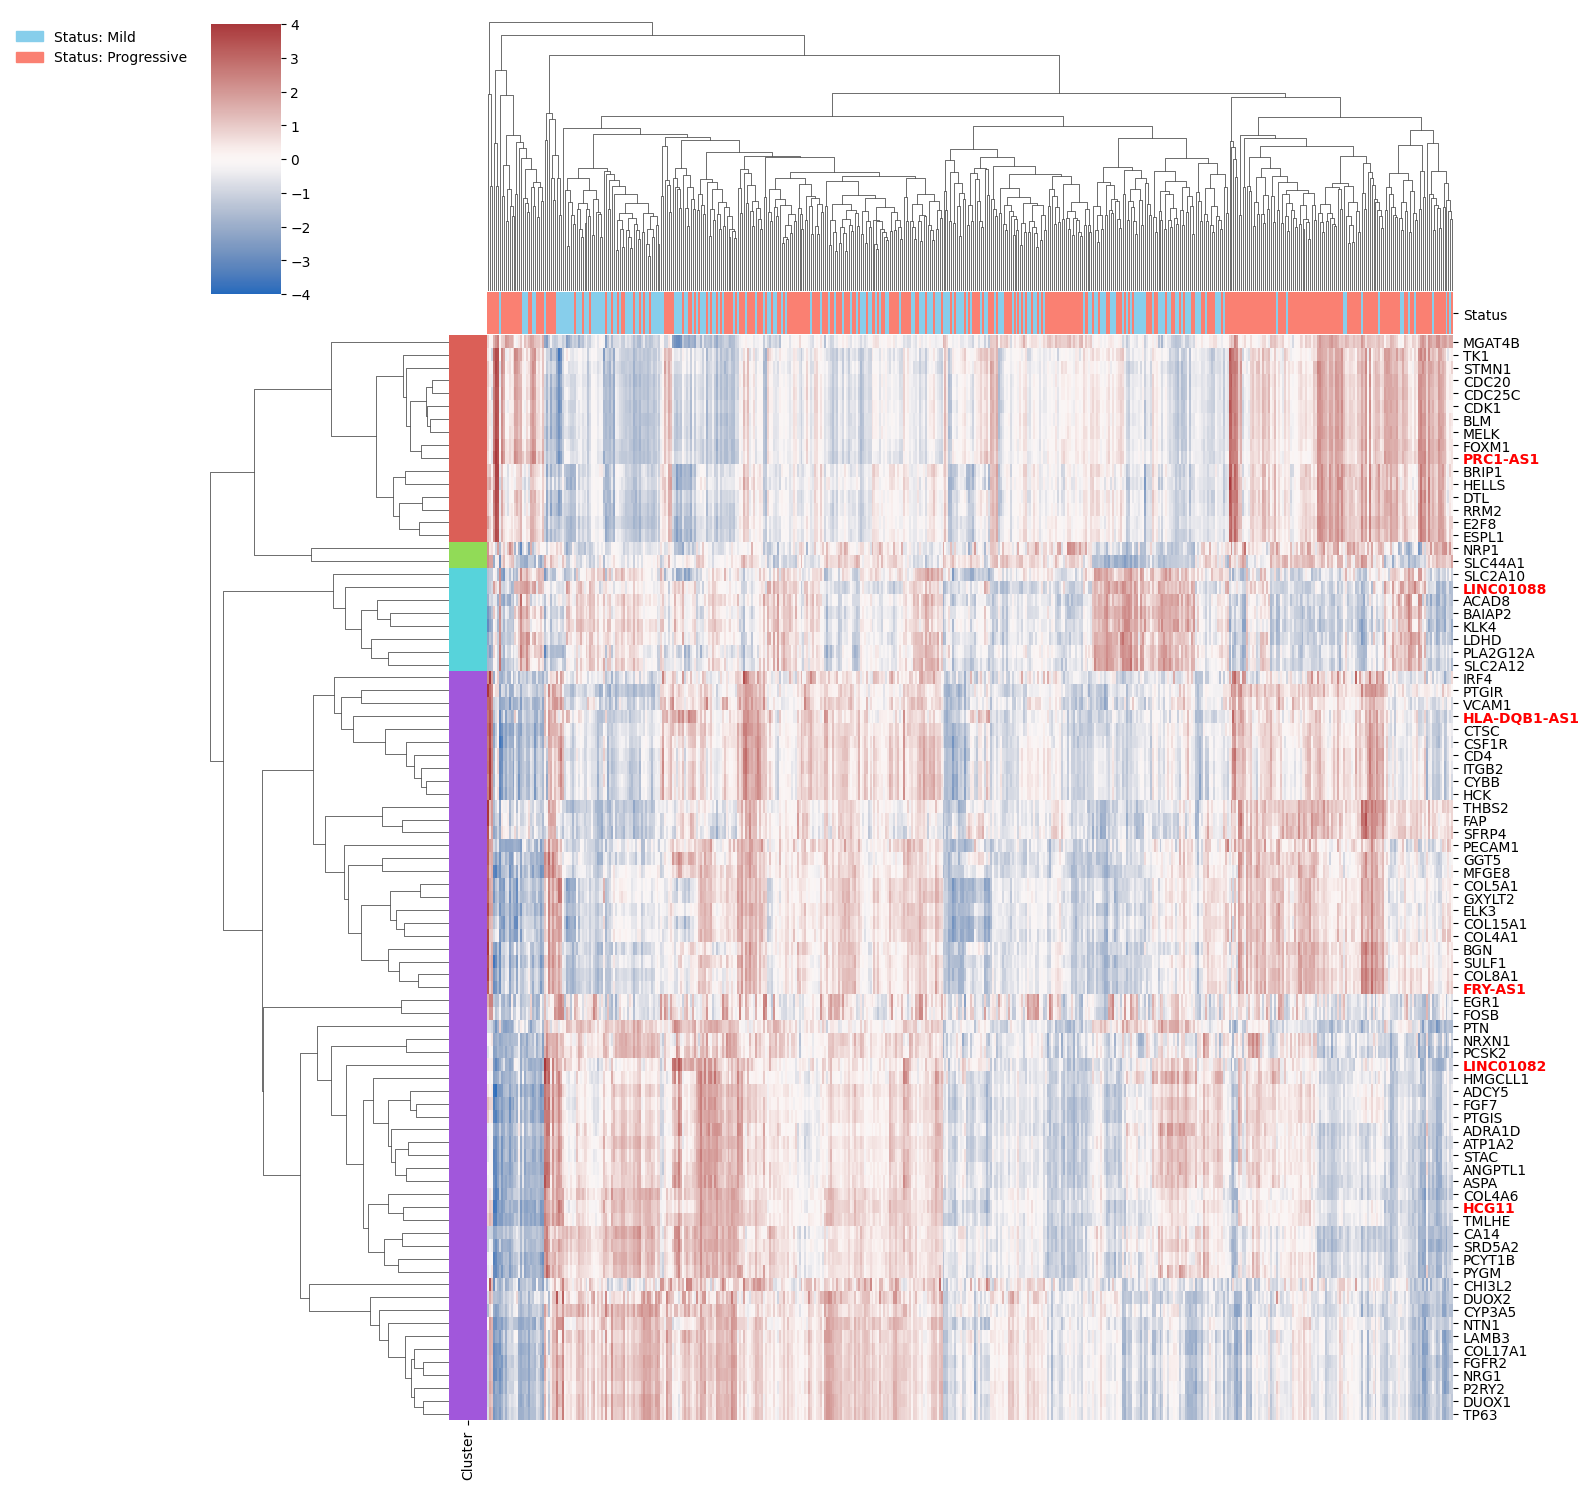


✅ Clustermap saved to: ../../figures/TCGA_clustermap_highlightNC_clustered_activity.png


In [77]:
# ============================================================
# TCGA Heatmap with Clustering and "NC" Gene Highlighting
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import fcluster

# -----------------------------
# Load data
# -----------------------------
count_matrix = pd.read_csv("../../../data/TCGA/activity_ens.csv", index_col=0)
clinical = pd.read_excel("../../../data/TCGA/clinical_info.xlsx")

# Set Sample_ID as index
clinical = clinical.set_index('Sample_ID')

# Keep only samples present in both datasets
common_samples = count_matrix.columns.intersection(clinical.index)
count_matrix = count_matrix[common_samples]
clinical = clinical.loc[common_samples]

# -----------------------------
# Prepare res_tcga_filt and gene list
# -----------------------------
# Ensure res_tcga_filt is defined before this script
# It should have columns: ['ID', 'Type']

# Clean Ensembl IDs (remove version numbers if present)
count_matrix.index = count_matrix.index.str.replace(r'\.\d+$', '', regex=True)
if 'ID' in res_tcga_filt.columns:
    res_tcga_filt['ID'] = res_tcga_filt['ID'].str.replace(r'\.\d+$', '', regex=True)

# Define genes of interest (Type == "NC")
genes_of_interest = res_tcga_filt.loc[res_tcga_filt['Type'] == "NC", 'ID'].tolist()

# Subset count matrix to only include relevant genes
valid_genes = count_matrix.index.intersection(res_tcga_filt['ID'].tolist())
count_matrix_subset = count_matrix.loc[valid_genes]

# Check for empty subset
if count_matrix_subset.empty:
    raise ValueError(
        "❌ count_matrix_subset is empty — check that gene IDs in count_matrix "
        "and res_tcga_filt['ID'] use the same format (e.g., remove version numbers)."
    )

print(f"✅ Subset created: {count_matrix_subset.shape[0]} genes × {count_matrix_subset.shape[1]} samples")

# -----------------------------
# Create color palette for Status annotation only
# -----------------------------
status_colors = {'Mild': 'skyblue', 'Progressive': 'salmon'}
col_colors = pd.DataFrame({
    'Status': clinical['Status'].map(status_colors)
})

# -----------------------------
# Cluster genes (rows)
# -----------------------------
k = 4  # number of row clusters

# Create initial clustermap (for row linkage extraction)
g_tmp = sns.clustermap(
    count_matrix_subset,
    cmap="vlag",
    z_score=0,
    row_cluster=True,
    col_cluster=True,
    xticklabels=False,
    yticklabels=False,
    figsize=(10, 10)
)
row_linkage = g_tmp.dendrogram_row.linkage
plt.close(g_tmp.fig)  # close temporary plot

# Extract row clusters
row_clusters = fcluster(row_linkage, k, criterion='maxclust')

# Assign colors to clusters
cluster_palette = sns.color_palette("hls", k)
cluster_colors = {i: cluster_palette[i-1] for i in range(1, k+1)}
row_colors = pd.DataFrame(
    {"Cluster": [cluster_colors[c] for c in row_clusters]},
    index=count_matrix_subset.index
)

# -----------------------------
# Map genes to clusters and save
# -----------------------------
gene_clusters = pd.DataFrame({
    'Gene': count_matrix_subset.index,
    'Cluster': row_clusters
})
gene_clusters.to_csv("../../figures/TCGA_gene_clusters_heatmap.csv", index=False)

# Dictionary of genes per cluster
genes_per_cluster = {
    i: gene_clusters[gene_clusters['Cluster'] == i]['Gene'].tolist()
    for i in range(1, k + 1)
}

# Print clusters summary
for cluster_id, genes in genes_per_cluster.items():
    print(f"\nCluster {cluster_id} ({len(genes)} genes):")
    print(genes)

# -----------------------------
# Final clustered heatmap with row_colors
# -----------------------------
g = sns.clustermap(
    count_matrix_subset,
    cmap="vlag",
    z_score=0,
    row_cluster=True,
    col_cluster=True,
    col_colors=col_colors,
    row_colors=row_colors,
    xticklabels=False,
    yticklabels=True,
    figsize=(14, 15),
    vmin=-4,
    vmax=4
)

# Highlight "NC" genes in red
ax = g.ax_heatmap
for label in ax.get_yticklabels():
    if label.get_text() in genes_of_interest:
        label.set_color("red")
        label.set_fontweight("bold")

# -----------------------------
# Add legend (Status only)
# -----------------------------
legend_patches = [
    Patch(color=color, label=f"Status: {label}")
    for label, color in status_colors.items()
]

plt.legend(
    handles=legend_patches,
    bbox_to_anchor=(-0.25, 1),
    loc='upper right',
    borderaxespad=0.,
    frameon=False
)

# -----------------------------
# Save final figure
# -----------------------------
output_path = "../../figures/TCGA_clustermap_highlightNC_clustered_activity.png"
g.fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n✅ Clustermap saved to: {output_path}")
